In [ ]:
# Title: PCR_killifish_atlas.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the PCR clock on Atlas 

# Set Up

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.stats import poisson
#from pydeseq2.dds import DeseqDataSet
#from pydeseq2.ds import DeseqStats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
from matplotlib.lines import Line2D
# Step 1: Import necessary libraries
from sklearn.decomposition import PCA
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
#from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [3]:
os.chdir("/labs/twc/Emma/Atlas_feature_importance/PCR_outs/")

In [4]:
# List of directories you want to create
dirs_to_create = [
    "./predictions/",
    "./gene_sets/",
    "./plots/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

In [5]:
df_norm = pd.read_csv("../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [6]:
df_norm = df_norm.T

In [7]:
df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,913.804009,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,774.447946,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,520.497299,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,1201.386683,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,420.973787,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940


In [8]:
df_norm_frequency = df_norm.div(df_norm.sum(axis=1), axis=0)

In [9]:
df_metadata = pd.read_csv("../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [10]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [11]:
df_metadata.set_index("sample", inplace=True)

In [12]:
# Merge based on index
combined_df = pd.concat([df_norm_frequency, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

In [13]:
combined_df["tissue"].value_counts()

Gut           55
Kidney        55
Muscle        55
Spleen        55
SpinalCord    54
Heart         54
Skin          54
Brain         54
Liver         54
Fat           53
Bone          51
Eye           37
Testis        31
Ovary         15
Name: tissue, dtype: int64

In [14]:
df_norm_metadata = pd.concat([df_norm, df_metadata[["sex", "tissue", "age_days"]]], axis=1)

df_norm_metadata.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47


# Function definitions

### PCR normal

In [22]:
def run_pcr(
    df: pd.DataFrame,
    tissue_name: str,
    pred_root: str = "./predictions",
    genesets_root: str = "./gene_sets",
    plots_root: str = "./plots",
    pc_start: int = 1,
    pc_stop: int = 21,   # exclusive; 21 -> runs through 20
    pc_step: int = 1
) -> pd.DataFrame:
    """
    Runs Principal Components Regression (PCR) with LOOCV for a range of PCs,
    using the ORIGINAL (leakage-prone) approach:
      - Standardize features ONCE on full data
      - Fit PCA ONCE per n_components on full standardized data
      - Cross-validate LinearRegression on precomputed PC scores

    Assumes df's last column is the target (age), all others are features (genes).

    Outputs (under tissue-specific subfolders):
      ./predictions/<tissue>/<tissue>_PCR_LOOCV_predictions_PC{n}.csv
      ./predictions/<tissue>/<tissue>_PCR_LOOCV_predictions_long_PC5_to_PC20.csv
      ./predictions/<tissue>/<tissue>_PCR_metrics_PC5_to_PC20.csv
      ./plots/<tissue>/<tissue>_PCR_LOOCV_PC{n}.png
      ./gene_sets/<tissue>/<tissue>_PCA_explained_variance_PC{n}.csv
      ./gene_sets/<tissue>/<tissue>_PCA_loadings_PC{n}.csv
      ./gene_sets/<tissue>/<tissue>_PCR_gene_ranking_products_PC{n}.csv

    Returns:
        metrics_df (pd.DataFrame): per-PC metrics summary.
    """
    # Directories
    pred_dir = os.path.join(pred_root, tissue_name)
    genesets_dir = os.path.join(genesets_root, tissue_name)
    plots_dir = os.path.join(plots_root, tissue_name)
    for d in [pred_dir, genesets_dir, plots_dir]:
        os.makedirs(d, exist_ok=True)

    # Data
    data = df.values
    age = data[:, -1]
    X = data[:, :-1]

    # Fit scaler ONCE on full X (leakage preserved by design)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Feature (gene) names
    if isinstance(df, pd.DataFrame) and df.shape[1] == X.shape[1] + 1:
        feature_cols = list(df.columns[:-1])
    else:
        feature_cols = [f"feat_{i}" for i in range(X.shape[1])]

    # Collectors
    metrics_rows = []
    all_preds = []

    # Loop over PC counts
    for n_comp in range(pc_start, pc_stop, pc_step):
        # PCA on full standardized X (leakage)
        pca = PCA(n_components=n_comp, random_state=1)
        X_pca = pca.fit_transform(X_scaled)

        # PCR model
        regressor = LinearRegression()

        # LOOCV predictions on precomputed PCs
        y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

        # Metrics
        MAE = mean_absolute_error(age, y_pred)
        r2 = r2_score(age, y_pred)
        pearson_corr, _ = pearsonr(age, y_pred)

        print(f"[{tissue_name} | PCs={n_comp}] MAE: {MAE:.4f} | R²: {r2:.4f} | Pearson: {pearson_corr:.4f}")

        # Save per-PC predictions
        preds_df = pd.DataFrame({
            "sample_idx": np.arange(len(age)),
            "actual_age": age,
            f"pred_age_PC{n_comp}": y_pred
        })
        preds_path = os.path.join(pred_dir, f"{tissue_name}_PCR_LOOCV_predictions_PC{n_comp}.csv")
        preds_df.to_csv(preds_path, index=False)

        # Long-form collector
        tmp = preds_df[["sample_idx", "actual_age", f"pred_age_PC{n_comp}"]].copy()
        tmp = tmp.rename(columns={f"pred_age_PC{n_comp}": "pred_age"})
        tmp["n_components"] = n_comp
        all_preds.append(tmp)

        # Plot Actual vs Predicted
        plt.figure(figsize=(10, 7))
        plt.scatter(age, y_pred, alpha=0.7, color='b')
        plt.xlabel('Actual Age')
        plt.ylabel('Predicted Age')
        plt.title(f'{tissue_name} Actual vs. Predicted Age (LOOCV)\n'
                  f'R² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First {n_comp} Components')
        plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
        plt.text(age.min() + 0.05 * (age.max() - age.min()),
                 age.max() - 0.2 * (age.max() - age.min()),
                 f'MAE = {MAE:.2f}', fontsize=12, color='blue')
        plt.text(age.min() + 0.05 * (age.max() - age.min()),
                 age.max() - 0.1 * (age.max() - age.min()),
                 f'R² = {r2:.2f}', fontsize=12, color='blue')
        plt.text(age.min() + 0.05 * (age.max() - age.min()),
                 age.max() - 0.15 * (age.max() - age.min()),
                 f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')
        plot_path = os.path.join(plots_dir, f"{tissue_name}_PCR_LOOCV_PC{n_comp}.png")
        plt.tight_layout()
        plt.savefig(plot_path, dpi=300)
        plt.close()

        # Explained variance & cumulative
        explained_variance = pca.explained_variance_ratio_
        cumulative_explained_variance = explained_variance.cumsum()

        ev_df = pd.DataFrame({
            "PC": np.arange(1, n_comp + 1),
            "explained_variance_ratio": explained_variance,
            "cumulative_explained_variance_ratio": cumulative_explained_variance
        })
        ev_path = os.path.join(genesets_dir, f"{tissue_name}_PCA_explained_variance_PC{n_comp}.csv")
        ev_df.to_csv(ev_path, index=False)

        # Loadings per PC
        loadings = pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(n_comp)])
        loadings.insert(0, "feature", feature_cols)
        loadings_path = os.path.join(genesets_dir, f"{tissue_name}_PCA_loadings_PC{n_comp}.csv")
        loadings.to_csv(loadings_path, index=False)

        # Gene ranking products: loading(gene, PCk) * coef(PCk), plus row-wise sum
        regressor_full = LinearRegression()
        regressor_full.fit(X_pca, age)
        pc_coefs = regressor_full.coef_  # shape: (n_comp,)

        loadings_mat = pca.components_.T  # (n_genes, n_comp)
        products_mat = loadings_mat * pc_coefs  # broadcast across columns

        product_cols = [f"PC{i+1}" for i in range(n_comp)]
        products_df = pd.DataFrame(products_mat, columns=product_cols)
        products_df.insert(0, "gene", feature_cols)
        products_df["sum_products"] = products_df[product_cols].sum(axis=1)

        products_path = os.path.join(genesets_dir, f"{tissue_name}_PCR_gene_ranking_products_PC{n_comp}.csv")
        products_df.to_csv(products_path, index=False)

        # Metrics row
        metrics_rows.append({
            "tissue": tissue_name,
            "n_components": n_comp,
            "MAE": MAE,
            "R2": r2,
            "Pearson": pearson_corr,
            "Cumulative_Explained_Variance": cumulative_explained_variance[-1]
        })

    # Save summary tables
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_path = os.path.join(pred_dir, f"{tissue_name}_PCR_metrics_PC{pc_start}_to_PC{pc_stop-1}.csv")
    metrics_df.to_csv(metrics_path, index=False)

    if len(all_preds) > 0:
        preds_long = pd.concat(all_preds, ignore_index=True)
        preds_long_path = os.path.join(pred_dir, f"{tissue_name}_PCR_LOOCV_predictions_long_PC{pc_start}_to_PC{pc_stop-1}.csv")
        preds_long.to_csv(preds_long_path, index=False)

    print("Saved outputs to:")
    print(f"  Predictions per-PC: {pred_dir}/")
    print(f"  Metrics summary:    {metrics_path}")
    print(f"  Plots per-PC:       {plots_dir}/")
    print(f"  EV & loadings:      {genesets_dir}/")
    print(f"  Products tables:    {genesets_dir}/ (one per PC count)")

    return metrics_df


### Leakage-safe

In [23]:
def run_pcr_leakageSafe(
    df: pd.DataFrame,
    tissue_name: str,
    pred_root: str = "./predictions",
    genesets_root: str = "./gene_sets",
    plots_root: str = "./plots",
    pc_start: int = 1,
    pc_stop: int = 26,   # exclusive (default runs 5,10,15,20,25)
    pc_step: int = 1
) -> pd.DataFrame:
    """
    Leakage-safe Principal Components Regression (PCR) with LOOCV.
    - Scaler + PCA + LinearRegression are refit inside each CV fold via Pipeline.
    - Tests PCs in range(pc_start, pc_stop, pc_step).
    - Saves per-PC predictions, plots, explained variance, loadings, and
      gene-ranking products (loading * PC weight), plus a metrics summary and
      MAE/R² comparison plots. All outputs are suffixed with `_leakageSafe`.

    Assumptions:
      - df: last column is the target (age), all preceding columns are features (genes).

    Returns:
      metrics_df (pd.DataFrame): per-PC metrics summary.
    """

    # ------------------------------
    # Setup directories
    # ------------------------------
    pred_dir = os.path.join(pred_root, tissue_name)
    genesets_dir = os.path.join(genesets_root, tissue_name)
    plots_dir = os.path.join(plots_root, tissue_name)
    for d in [pred_dir, genesets_dir, plots_dir]:
        os.makedirs(d, exist_ok=True)

    # ------------------------------
    # Data
    # ------------------------------
    data = df.values
    age = data[:, -1]
    X = data[:, :-1]

    # Gene names
    if isinstance(df, pd.DataFrame) and df.shape[1] == X.shape[1] + 1:
        feature_cols = list(df.columns[:-1])
    else:
        feature_cols = [f"feat_{i}" for i in range(X.shape[1])]

    # Collectors
    metrics_rows = []
    all_preds = []

    # ------------------------------
    # Loop over PCs (LEAKAGE-SAFE)
    # ------------------------------
    for n_comp in range(pc_start, pc_stop, pc_step):
        # Pipeline ensures scaler+PCA+LR are fit per fold (no leakage)
        pipe = Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_comp, random_state=1)),
            ("lr", LinearRegression())
        ])

        # LOOCV predictions
        y_pred = cross_val_predict(pipe, X, age, cv=len(age))

        # Metrics
        MAE = mean_absolute_error(age, y_pred)
        r2 = r2_score(age, y_pred)
        pearson_corr, _ = pearsonr(age, y_pred)

        print(f"[{tissue_name} | LEAK-SAFE PCs={n_comp}] "
              f"MAE: {MAE:.4f} | R²: {r2:.4f} | Pearson: {pearson_corr:.4f}")

        # --- Predictions (per PC count) ---
        preds_df = pd.DataFrame({
            "sample_idx": np.arange(len(age)),
            "actual_age": age,
            f"pred_age_PC{n_comp}_leakageSafe": y_pred
        })
        preds_path = os.path.join(
            pred_dir, f"{tissue_name}_PCR_LOOCV_predictions_PC{n_comp}_leakageSafe.csv"
        )
        preds_df.to_csv(preds_path, index=False)

        # Long-form collector
        tmp = preds_df[["sample_idx", "actual_age", f"pred_age_PC{n_comp}_leakageSafe"]].copy()
        tmp = tmp.rename(columns={f"pred_age_PC{n_comp}_leakageSafe": "pred_age"})
        tmp["n_components"] = n_comp
        all_preds.append(tmp)

        # --- Plot Actual vs Predicted (per PC count) ---
        plt.figure(figsize=(10, 7))
        plt.scatter(age, y_pred, alpha=0.7)
        plt.xlabel('Actual Age')
        plt.ylabel('Predicted Age')
        plt.title(f'{tissue_name} Actual vs. Predicted Age (LOOCV, leakage-safe)\n'
                  f'R² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First {n_comp} Components')
        plt.plot([age.min(), age.max()], [age.min(), age.max()], '--', lw=2)
        plt.text(age.min() + 0.05 * (age.max() - age.min()),
                 age.max() - 0.2 * (age.max() - age.min()),
                 f'MAE = {MAE:.2f}', fontsize=12)
        plt.text(age.min() + 0.05 * (age.max() - age.min()),
                 age.max() - 0.1 * (age.max() - age.min()),
                 f'R² = {r2:.2f}', fontsize=12)
        plt.text(age.min() + 0.05 * (age.max() - age.min()),
                 age.max() - 0.15 * (age.max() - age.min()),
                 f'Pearson = {pearson_corr:.2f}', fontsize=12)
        plot_path = os.path.join(
            plots_dir, f"{tissue_name}_PCR_LOOCV_PC{n_comp}_leakageSafe.png"
        )
        plt.tight_layout()
        plt.savefig(plot_path, dpi=300)
        plt.close()

        # -------------------------------------------------------
        # Full-data fit (ONLY for reporting EV/loadings/products)
        # -------------------------------------------------------
        pipe_full = pipe.fit(X, age)
        pca_full = pipe_full.named_steps["pca"]
        lr_full = pipe_full.named_steps["lr"]

        # Explained variance & cumulative
        explained_variance = pca_full.explained_variance_ratio_
        cumulative_explained_variance = explained_variance.cumsum()

        ev_df = pd.DataFrame({
            "PC": np.arange(1, n_comp + 1),
            "explained_variance_ratio": explained_variance,
            "cumulative_explained_variance_ratio": cumulative_explained_variance
        })
        ev_path = os.path.join(
            genesets_dir, f"{tissue_name}_PCA_explained_variance_PC{n_comp}_leakageSafe.csv"
        )
        ev_df.to_csv(ev_path, index=False)

        # Loadings per PC
        loadings = pd.DataFrame(
            pca_full.components_.T, columns=[f"PC{i+1}" for i in range(n_comp)]
        )
        loadings.insert(0, "feature", feature_cols)
        loadings_path = os.path.join(
            genesets_dir, f"{tissue_name}_PCA_loadings_PC{n_comp}_leakageSafe.csv"
        )
        loadings.to_csv(loadings_path, index=False)

        # Gene ranking products: loading(gene, PCk) * coef(PCk), plus sum across PCs
        pc_coefs = lr_full.coef_                # shape: (n_comp,)
        loadings_mat = pca_full.components_.T   # (n_genes, n_comp)
        products_mat = loadings_mat * pc_coefs  # broadcast multiply by column

        product_cols = [f"PC{i+1}" for i in range(n_comp)]
        products_df = pd.DataFrame(products_mat, columns=product_cols)
        products_df.insert(0, "gene", feature_cols)
        products_df["sum_products"] = products_df[product_cols].sum(axis=1)

        products_path = os.path.join(
            genesets_dir, f"{tissue_name}_PCR_gene_ranking_products_PC{n_comp}_leakageSafe.csv"
        )
        products_df.to_csv(products_path, index=False)

        # Metrics row
        metrics_rows.append({
            "tissue": tissue_name,
            "n_components": n_comp,
            "MAE": MAE,
            "R2": r2,
            "Pearson": pearson_corr,
            "Cumulative_Explained_Variance": cumulative_explained_variance[-1]
        })

    # ------------------------------
    # Save summary tables
    # ------------------------------
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_path = os.path.join(
        pred_dir, f"{tissue_name}_PCR_metrics_PC{pc_start}_to_PC{pc_stop-1}_step{pc_step}_leakageSafe.csv"
    )
    metrics_df.to_csv(metrics_path, index=False)

    if len(all_preds) > 0:
        preds_long = pd.concat(all_preds, ignore_index=True)
        preds_long_path = os.path.join(
            pred_dir, f"{tissue_name}_PCR_LOOCV_predictions_long_PC{pc_start}_to_PC{pc_stop-1}_step{pc_step}_leakageSafe.csv"
        )
        preds_long.to_csv(preds_long_path, index=False)

    print("Saved outputs to:")
    print(f"  Predictions per-PC: {pred_dir}/")
    print(f"  Metrics summary:    {metrics_path}")
    print(f"  Plots per-PC:       {plots_dir}/")
    print(f"  EV & loadings:      {genesets_dir}/")
    print(f"  Products tables:    {genesets_dir}/ (one per PC count)")

    # ------------------------------
    # Comparison plots across PCs (MAE & R²) — leakage-safe
    # ------------------------------
    metrics_df_sorted = metrics_df.sort_values("n_components")

    # MAE vs #PCs
    plt.figure(figsize=(7, 5))
    plt.plot(metrics_df_sorted["n_components"], metrics_df_sorted["MAE"], marker="o")
    plt.xlabel("Number of PCs")
    plt.ylabel("MAE (LOOCV)")
    plt.title(f"{tissue_name}: MAE vs. #PCs (LOOCV, leakage-safe)")
    plt.grid(True, linestyle="--", alpha=0.5)
    mae_plot_path = os.path.join(
        plots_dir, f"{tissue_name}_PCR_MAE_vs_PCs_step{pc_step}_leakageSafe.png"
    )
    plt.tight_layout()
    plt.savefig(mae_plot_path, dpi=300)
    plt.close()

    # R² vs #PCs
    plt.figure(figsize=(7, 5))
    plt.plot(metrics_df_sorted["n_components"], metrics_df_sorted["R2"], marker="o")
    plt.xlabel("Number of PCs")
    plt.ylabel("R² (LOOCV)")
    plt.title(f"{tissue_name}: R² vs. #PCs (LOOCV, leakage-safe)")
    plt.grid(True, linestyle="--", alpha=0.5)
    r2_plot_path = os.path.join(
        plots_dir, f"{tissue_name}_PCR_R2_vs_PCs_step{pc_step}_leakageSafe.png"
    )
    plt.tight_layout()
    plt.savefig(r2_plot_path, dpi=300)
    plt.close()

    print(f"Saved comparison plots:\n  {mae_plot_path}\n  {r2_plot_path}")

    return metrics_df


# Gut

In [24]:
gut_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Gut"]

gut_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,M,Gut,133
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,F,Gut,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,F,Gut,75
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,M,Gut,134


In [25]:
gut_df_norm_expression = gut_df_norm.iloc[:,:-3]

gut_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,913.804009,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,1070.748070,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,804.677628,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,770.127782,163.039100,1112.112236,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,816.301700,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254


In [26]:
gut_pca_df = gut_df_norm_expression.copy()

gut_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,913.804009,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,1070.748070,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,804.677628,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,770.127782,163.039100,1112.112236,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,816.301700,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254


In [27]:
gut_pca_df["age"] = gut_df_norm["age_days"].tolist()

gut_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,163.039100,1112.112236,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,75
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,134


### Run all PCs 

In [28]:
metrics_gut = run_pcr(gut_pca_df, "Gut")

[Gut | PCs=1] MAE: 36.8803 | R²: -0.0208 | Pearson: 0.1657
[Gut | PCs=2] MAE: 37.3706 | R²: -0.0453 | Pearson: 0.1450
[Gut | PCs=3] MAE: 38.2734 | R²: -0.0983 | Pearson: 0.0833
[Gut | PCs=4] MAE: 31.9903 | R²: 0.1507 | Pearson: 0.4214
[Gut | PCs=5] MAE: 32.0574 | R²: 0.1141 | Pearson: 0.4062
[Gut | PCs=6] MAE: 28.3726 | R²: 0.2740 | Pearson: 0.5621
[Gut | PCs=7] MAE: 19.8432 | R²: 0.5990 | Pearson: 0.7766
[Gut | PCs=8] MAE: 19.7008 | R²: 0.5105 | Pearson: 0.7522
[Gut | PCs=9] MAE: 18.7234 | R²: 0.5495 | Pearson: 0.7715
[Gut | PCs=10] MAE: 19.8037 | R²: 0.5143 | Pearson: 0.7573
[Gut | PCs=11] MAE: 19.4128 | R²: 0.5645 | Pearson: 0.7794
[Gut | PCs=12] MAE: 17.4497 | R²: 0.6507 | Pearson: 0.8172
[Gut | PCs=13] MAE: 18.0772 | R²: 0.6675 | Pearson: 0.8247
[Gut | PCs=14] MAE: 19.0957 | R²: 0.6376 | Pearson: 0.8116
[Gut | PCs=15] MAE: 17.7452 | R²: 0.6936 | Pearson: 0.8417
[Gut | PCs=16] MAE: 17.3882 | R²: 0.7046 | Pearson: 0.8479
[Gut | PCs=17] MAE: 17.0612 | R²: 0.7091 | Pearson: 0.8482
[Gu

### Single PC number

Mean Absolute Error (MAE) with LOOCV and opt components: 17.061164649947013
R² Score with LOOCV and 15 components: 0.709068329732019
Pearson Correlation Coefficient with opt components: 0.8482054655118111


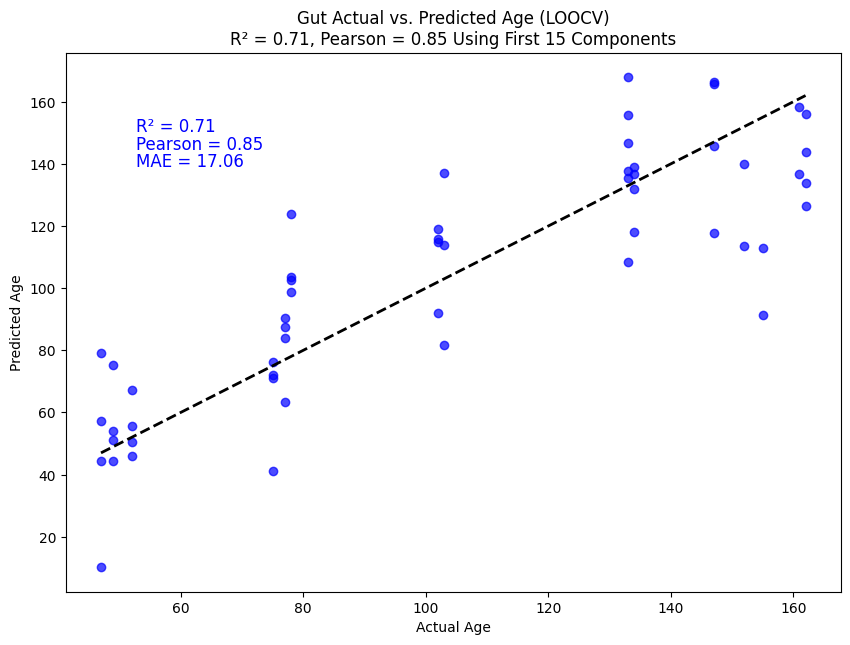

Explained variance by each component : [0.11141985 0.07706119 0.06303848 0.05464206 0.03798071 0.03201149
 0.02851742 0.02733091 0.02456679 0.0234613  0.02061888 0.0202061
 0.01909464 0.01735448 0.01696121 0.0154362  0.0146509 ]
Cumulative explained variance: [0.11141985 0.18848105 0.25151953 0.30616159 0.3441423  0.37615379
 0.40467121 0.43200212 0.45656892 0.48003022 0.50064909 0.52085519
 0.53994983 0.55730431 0.57426552 0.58970172 0.60435263]


In [29]:
gut_data = gut_pca_df.values

# Assuming gut_df_norm contains your normalized data with 'age_days' as the target variable
age = gut_data[:,-1]
X = gut_data[:,:-1]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA 
pca = PCA(n_components=17, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions 
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) 
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and opt components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 15 components: {r2}')

# Calculate Pearson correlation coefficient 
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with opt components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Gut Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 15 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for opt comp
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component : {explained_variance}')
print(f'Cumulative explained variance: {cumulative_explained_variance}')

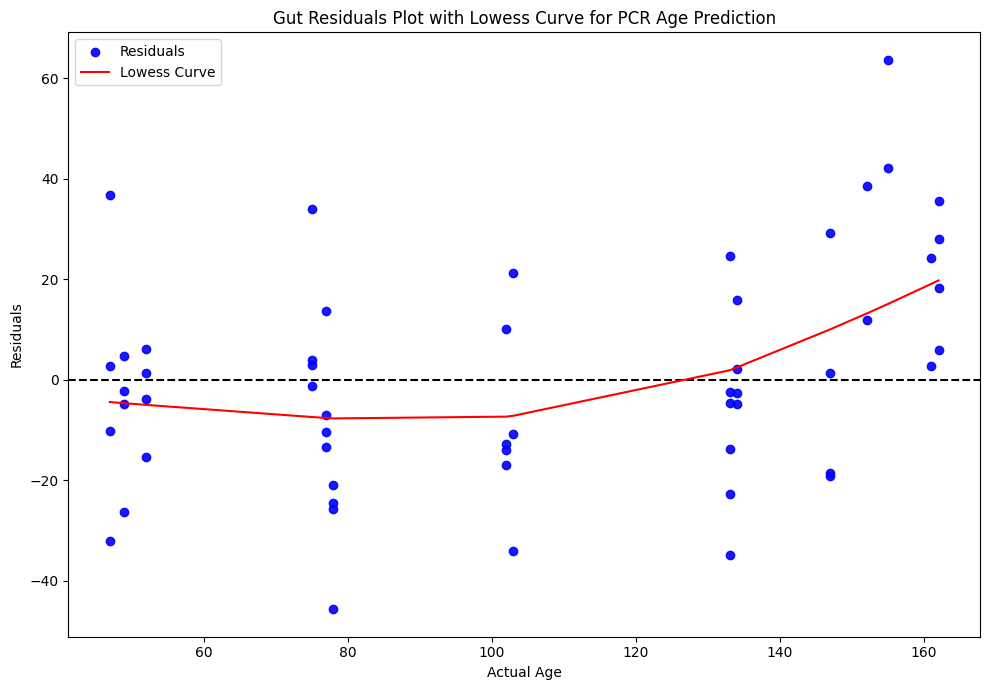

In [30]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Gut Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

### Leakage safe

In [31]:
metrics_gut = run_pcr_leakageSafe(gut_pca_df, "Gut")

[Gut | LEAK-SAFE PCs=1] MAE: 36.6699 | R²: 0.0108 | Pearson: 0.1694
[Gut | LEAK-SAFE PCs=2] MAE: 37.1002 | R²: -0.0158 | Pearson: 0.1445
[Gut | LEAK-SAFE PCs=3] MAE: 38.3386 | R²: -0.0946 | Pearson: 0.0417
[Gut | LEAK-SAFE PCs=4] MAE: 33.3822 | R²: 0.1486 | Pearson: 0.3921
[Gut | LEAK-SAFE PCs=5] MAE: 33.5634 | R²: 0.1199 | Pearson: 0.3694
[Gut | LEAK-SAFE PCs=6] MAE: 30.6567 | R²: 0.2205 | Pearson: 0.4716
[Gut | LEAK-SAFE PCs=7] MAE: 27.3046 | R²: 0.3790 | Pearson: 0.6186
[Gut | LEAK-SAFE PCs=8] MAE: 24.6852 | R²: 0.4968 | Pearson: 0.7226
[Gut | LEAK-SAFE PCs=9] MAE: 24.3405 | R²: 0.5136 | Pearson: 0.7379
[Gut | LEAK-SAFE PCs=10] MAE: 23.6877 | R²: 0.5365 | Pearson: 0.7545
[Gut | LEAK-SAFE PCs=11] MAE: 23.8671 | R²: 0.5314 | Pearson: 0.7502
[Gut | LEAK-SAFE PCs=12] MAE: 22.2863 | R²: 0.5675 | Pearson: 0.7749
[Gut | LEAK-SAFE PCs=13] MAE: 21.1998 | R²: 0.6027 | Pearson: 0.7993
[Gut | LEAK-SAFE PCs=14] MAE: 21.1899 | R²: 0.5975 | Pearson: 0.7965
[Gut | LEAK-SAFE PCs=15] MAE: 20.6198 | R

# Kidney

In [32]:
kidney_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Kidney"]

kidney_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090,F,Kidney,78
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901,M,Kidney,147


In [33]:
kidney_df_norm_expression = kidney_df_norm.iloc[:,:-3]

kidney_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,520.497299,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,420.973787,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,580.300010,119.559299,1335.564848,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,550.788736,183.098019,1128.481670,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,599.680828,100.414940,1393.871714,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901


In [34]:
kidney_pca_df = kidney_df_norm_expression.copy()

kidney_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,520.497299,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,420.973787,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,580.300010,119.559299,1335.564848,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,550.788736,183.098019,1128.481670,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,599.680828,100.414940,1393.871714,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901


In [35]:
kidney_pca_df["age"] = kidney_df_norm["age_days"].tolist()

kidney_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,133
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,47
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,119.559299,1335.564848,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,161
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,183.098019,1128.481670,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090,78
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,100.414940,1393.871714,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901,147


### Run all PCs

In [36]:
metrics_kidney = run_pcr(kidney_pca_df, "Kidney")
print(metrics_kidney)

[Kidney | PCs=1] MAE: 37.8926 | R²: -0.0394 | Pearson: -0.0108
[Kidney | PCs=2] MAE: 37.8761 | R²: -0.0323 | Pearson: 0.1220
[Kidney | PCs=3] MAE: 35.3173 | R²: 0.0618 | Pearson: 0.3011
[Kidney | PCs=4] MAE: 24.9151 | R²: 0.5001 | Pearson: 0.7097
[Kidney | PCs=5] MAE: 23.0143 | R²: 0.5383 | Pearson: 0.7381
[Kidney | PCs=6] MAE: 23.5492 | R²: 0.5156 | Pearson: 0.7247
[Kidney | PCs=7] MAE: 22.7196 | R²: 0.5259 | Pearson: 0.7324
[Kidney | PCs=8] MAE: 23.2922 | R²: 0.5229 | Pearson: 0.7320
[Kidney | PCs=9] MAE: 23.7574 | R²: 0.5146 | Pearson: 0.7292
[Kidney | PCs=10] MAE: 21.7243 | R²: 0.5853 | Pearson: 0.7754
[Kidney | PCs=11] MAE: 19.1779 | R²: 0.6799 | Pearson: 0.8294
[Kidney | PCs=12] MAE: 20.0897 | R²: 0.6438 | Pearson: 0.8099
[Kidney | PCs=13] MAE: 17.3465 | R²: 0.7031 | Pearson: 0.8449
[Kidney | PCs=14] MAE: 17.6507 | R²: 0.7124 | Pearson: 0.8550
[Kidney | PCs=15] MAE: 18.0212 | R²: 0.6816 | Pearson: 0.8399
[Kidney | PCs=16] MAE: 17.6102 | R²: 0.7054 | Pearson: 0.8514
[Kidney | PCs=

In [37]:
metrics_kidney = run_pcr_leakageSafe(kidney_pca_df, "Kidney")
print(metrics_kidney)

[Kidney | LEAK-SAFE PCs=1] MAE: 37.8390 | R²: -0.0390 | Pearson: -0.0232
[Kidney | LEAK-SAFE PCs=2] MAE: 38.1219 | R²: -0.0433 | Pearson: 0.0820
[Kidney | LEAK-SAFE PCs=3] MAE: 36.3839 | R²: 0.0341 | Pearson: 0.2444
[Kidney | LEAK-SAFE PCs=4] MAE: 25.5835 | R²: 0.4935 | Pearson: 0.7131
[Kidney | LEAK-SAFE PCs=5] MAE: 24.2371 | R²: 0.5316 | Pearson: 0.7383
[Kidney | LEAK-SAFE PCs=6] MAE: 24.6185 | R²: 0.5059 | Pearson: 0.7132
[Kidney | LEAK-SAFE PCs=7] MAE: 24.1880 | R²: 0.5189 | Pearson: 0.7213
[Kidney | LEAK-SAFE PCs=8] MAE: 24.1588 | R²: 0.5137 | Pearson: 0.7171
[Kidney | LEAK-SAFE PCs=9] MAE: 24.3325 | R²: 0.4957 | Pearson: 0.7044
[Kidney | LEAK-SAFE PCs=10] MAE: 22.7348 | R²: 0.5829 | Pearson: 0.7653
[Kidney | LEAK-SAFE PCs=11] MAE: 21.4915 | R²: 0.6282 | Pearson: 0.7966
[Kidney | LEAK-SAFE PCs=12] MAE: 21.7625 | R²: 0.6232 | Pearson: 0.7933
[Kidney | LEAK-SAFE PCs=13] MAE: 21.2805 | R²: 0.6370 | Pearson: 0.8037
[Kidney | LEAK-SAFE PCs=14] MAE: 19.8890 | R²: 0.6886 | Pearson: 0.838

### Single PC number

Mean Absolute Error (MAE) with LOOCV and 15 components: 18.0211508051028
R² Score with LOOCV and 15 components: 0.6815962089410046
Pearson Correlation Coefficient with 15 components: 0.8398717952493081


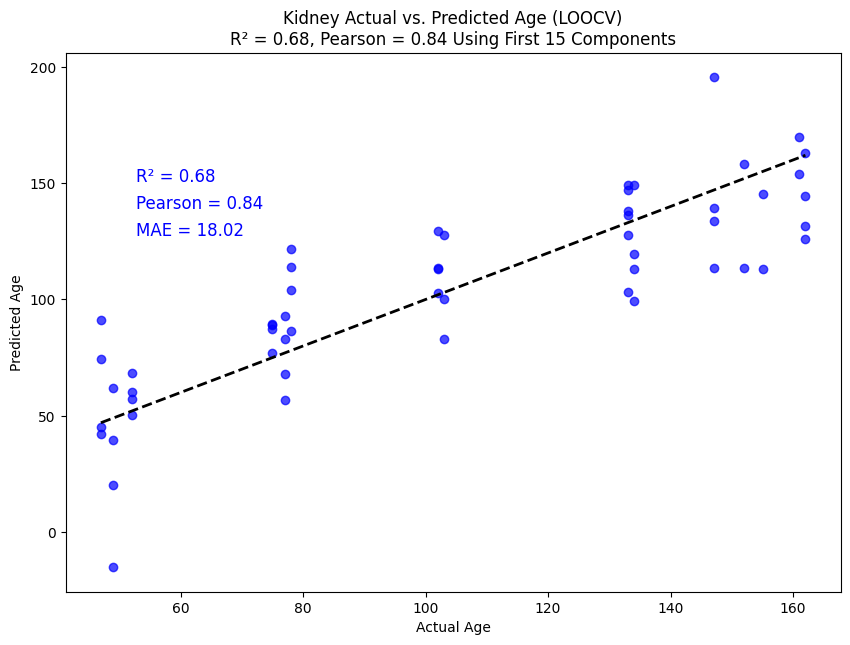

Explained variance by each component (15 components): [0.18767775 0.09092428 0.07013109 0.0536508  0.03888129 0.03649797
 0.0298901  0.02610706 0.02517992 0.02212155 0.01735721 0.01576364
 0.01533276 0.01519413 0.01312125]
Cumulative explained variance (15 components): [0.18767775 0.27860203 0.34873312 0.40238392 0.44126521 0.47776318
 0.50765329 0.53376035 0.55894027 0.58106182 0.59841903 0.61418267
 0.62951543 0.64470955 0.6578308 ]


In [38]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = kidney_df_norm['age_days']
X = kidney_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=15, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 15 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 15 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 15 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Kidney Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 15 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.3 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (15 components): {explained_variance}')
print(f'Cumulative explained variance (15 components): {cumulative_explained_variance}')

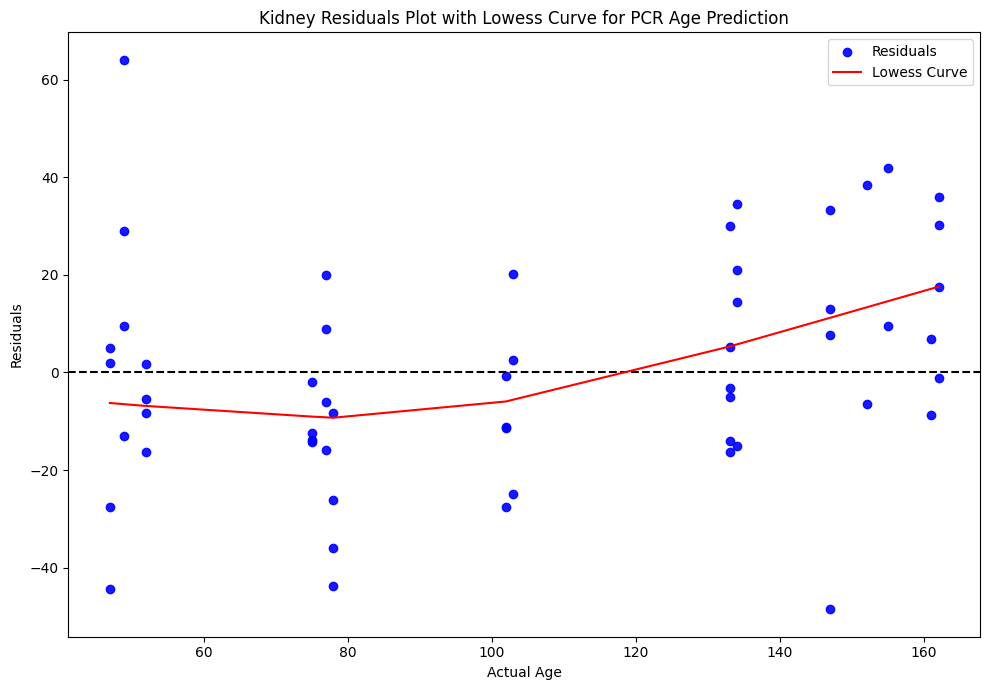

In [39]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Kidney Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

plt.legend()
plt.tight_layout()
plt.show()

# Muscle

In [40]:
muscle_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Muscle"]

muscle_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,M,Muscle,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,M,Muscle,52
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,F,Muscle,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,F,Muscle,155


In [41]:
muscle_df_norm_expression = muscle_df_norm.iloc[:,:-3]

muscle_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,700.569024,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,755.819358,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,642.836078,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,468.174077,40.781714,610.094442,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,706.723146,83.248090,825.395955,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427


In [42]:
muscle_pca_df = muscle_df_norm_expression.copy()

muscle_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,700.569024,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,755.819358,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,642.836078,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,468.174077,40.781714,610.094442,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,706.723146,83.248090,825.395955,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427


In [43]:
muscle_pca_df["age"] = muscle_df_norm["age_days"].tolist()

muscle_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,52
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,40.781714,610.094442,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,83.248090,825.395955,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,155


### Run all PCs

In [44]:
metrics_muscle = run_pcr(muscle_pca_df, "Muscle")
print(metrics_muscle)

metrics_muscle = run_pcr_leakageSafe(muscle_pca_df, "Muscle")
print(metrics_muscle)

[Muscle | PCs=1] MAE: 28.7310 | R²: 0.2301 | Pearson: 0.4984
[Muscle | PCs=2] MAE: 18.4769 | R²: 0.6801 | Pearson: 0.8256
[Muscle | PCs=3] MAE: 18.6384 | R²: 0.6738 | Pearson: 0.8219
[Muscle | PCs=4] MAE: 16.9980 | R²: 0.7501 | Pearson: 0.8666
[Muscle | PCs=5] MAE: 17.4923 | R²: 0.7409 | Pearson: 0.8615
[Muscle | PCs=6] MAE: 17.7396 | R²: 0.7394 | Pearson: 0.8608
[Muscle | PCs=7] MAE: 17.9996 | R²: 0.7299 | Pearson: 0.8555
[Muscle | PCs=8] MAE: 17.6357 | R²: 0.7353 | Pearson: 0.8590
[Muscle | PCs=9] MAE: 18.4079 | R²: 0.7109 | Pearson: 0.8463
[Muscle | PCs=10] MAE: 19.8656 | R²: 0.6104 | Pearson: 0.7993
[Muscle | PCs=11] MAE: 18.6751 | R²: 0.6838 | Pearson: 0.8359
[Muscle | PCs=12] MAE: 17.2769 | R²: 0.7053 | Pearson: 0.8477
[Muscle | PCs=13] MAE: 15.8145 | R²: 0.7591 | Pearson: 0.8755
[Muscle | PCs=14] MAE: 15.5882 | R²: 0.7741 | Pearson: 0.8828
[Muscle | PCs=15] MAE: 13.6100 | R²: 0.8295 | Pearson: 0.9126
[Muscle | PCs=16] MAE: 16.4643 | R²: 0.7566 | Pearson: 0.8741
[Muscle | PCs=17]

### Single PC number

Mean Absolute Error (MAE) with LOOCV and 15 components: 13.610027352844039
R² Score with LOOCV and 15 components: 0.829538328019334
Pearson Correlation Coefficient with 15 components: 0.9126016704053542


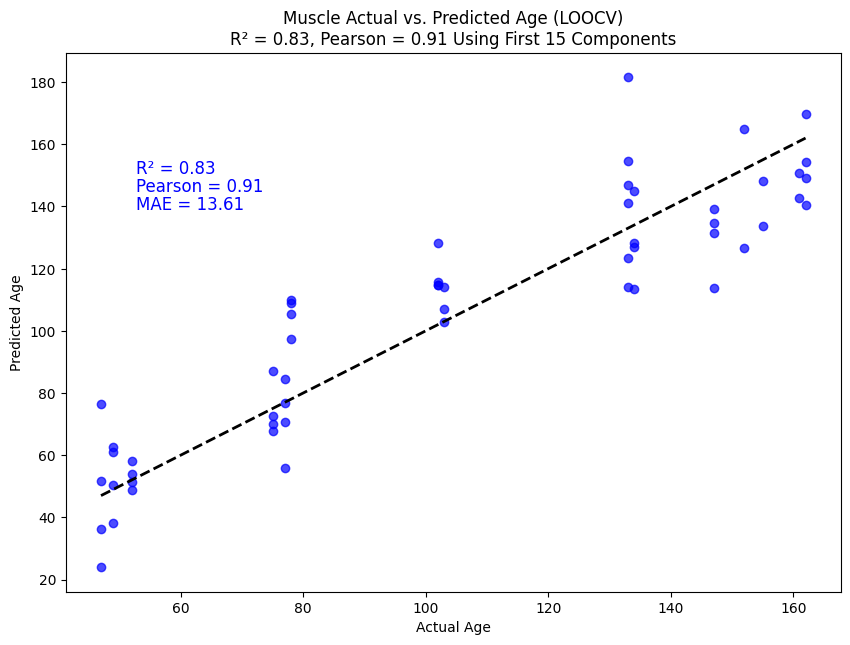

Explained variance by each component (15 components): [0.15445351 0.08756415 0.07124956 0.04606705 0.0380546  0.03240052
 0.02878692 0.02144411 0.02098096 0.01783881 0.01708315 0.01648456
 0.01602776 0.01497753 0.01342657]
Cumulative explained variance (15 components): [0.15445351 0.24201767 0.31326722 0.35933428 0.39738888 0.4297894
 0.45857632 0.48002043 0.50100139 0.5188402  0.53592335 0.55240791
 0.56843567 0.5834132  0.59683978]


In [45]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = muscle_df_norm['age_days']
X = muscle_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=15, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 15 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 15 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 15 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Muscle Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 15 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (15 components): {explained_variance}')
print(f'Cumulative explained variance (15 components): {cumulative_explained_variance}')

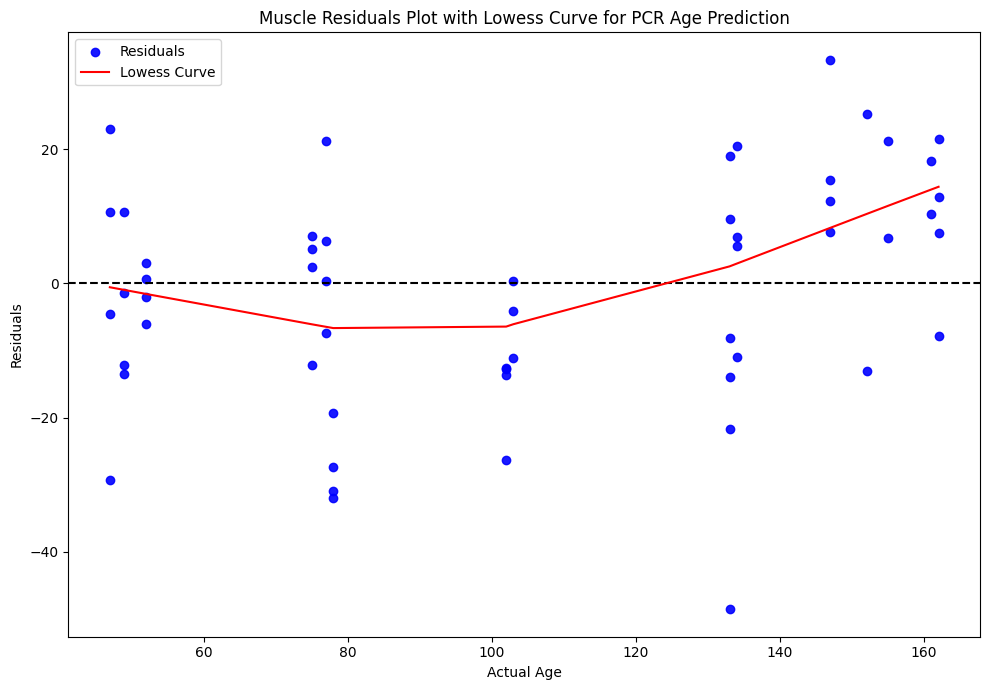

In [46]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Muscle Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Spleen

In [47]:
spleen_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Spleen"]

spleen_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,F,Spleen,78
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,M,Spleen,152
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,F,Spleen,155
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,M,Spleen,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,M,Spleen,102


In [48]:
spleen_df_norm_expression = spleen_df_norm.iloc[:,:-3]

spleen_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,503.101713,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,955.132396,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,1167.120293,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,611.783739,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,1406.295632,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715


In [49]:
spleen_pca_df = spleen_df_norm_expression.copy()

spleen_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,503.101713,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,955.132396,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,1167.120293,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,611.783739,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,1406.295632,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715


In [50]:
spleen_pca_df["age"] = spleen_df_norm["age_days"].tolist()

spleen_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,78
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,152
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,155
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,102


### Run all PCs

In [51]:
metrics_spleen = run_pcr(spleen_pca_df, "Spleen")
print(metrics_spleen)

metrics_spleen = run_pcr_leakageSafe(spleen_pca_df, "Spleen")
print(metrics_spleen)

[Spleen | PCs=1] MAE: 37.9179 | R²: -0.0599 | Pearson: -0.1798
[Spleen | PCs=2] MAE: 37.7051 | R²: -0.1251 | Pearson: 0.0925
[Spleen | PCs=3] MAE: 36.9051 | R²: -0.0325 | Pearson: 0.2394
[Spleen | PCs=4] MAE: 31.9053 | R²: 0.1412 | Pearson: 0.4342
[Spleen | PCs=5] MAE: 32.2135 | R²: 0.0779 | Pearson: 0.4406
[Spleen | PCs=6] MAE: 32.9347 | R²: 0.0425 | Pearson: 0.4212
[Spleen | PCs=7] MAE: 33.5548 | R²: -0.0151 | Pearson: 0.3954
[Spleen | PCs=8] MAE: 20.7473 | R²: 0.5967 | Pearson: 0.7800
[Spleen | PCs=9] MAE: 20.2648 | R²: 0.6191 | Pearson: 0.7922
[Spleen | PCs=10] MAE: 20.2893 | R²: 0.6177 | Pearson: 0.7912
[Spleen | PCs=11] MAE: 21.3663 | R²: 0.5860 | Pearson: 0.7746
[Spleen | PCs=12] MAE: 21.8727 | R²: 0.5685 | Pearson: 0.7662
[Spleen | PCs=13] MAE: 21.8572 | R²: 0.5589 | Pearson: 0.7603
[Spleen | PCs=14] MAE: 22.7332 | R²: 0.5066 | Pearson: 0.7337
[Spleen | PCs=15] MAE: 23.9654 | R²: 0.3964 | Pearson: 0.6865
[Spleen | PCs=16] MAE: 25.8225 | R²: 0.0431 | Pearson: 0.5850
[Spleen | PC

### Single PC number

Mean Absolute Error (MAE) with LOOCV and 10 components: 20.289340415166837
R² Score with LOOCV and 10 components: 0.617731170241113
Pearson Correlation Coefficient with 10 components: 0.7911920312187581


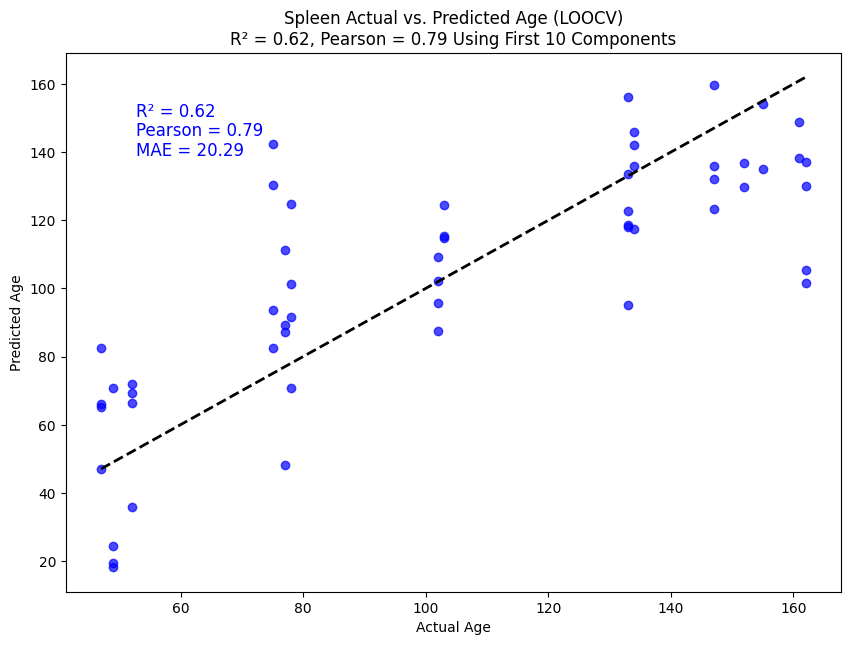

Explained variance by each component (10 components): [0.19186911 0.085535   0.07177656 0.05923945 0.05296658 0.0387825
 0.03429526 0.02694877 0.02421569 0.02055195]
Cumulative explained variance (10 components): [0.19186911 0.27740411 0.34918068 0.40842012 0.4613867  0.5001692
 0.53446446 0.56141323 0.58562892 0.60618086]


In [52]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = spleen_df_norm['age_days']
X = spleen_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with optimal components
pca = PCA(n_components=10, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 10 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 10 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 10 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Spleen Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 10 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (10 components): {explained_variance}')
print(f'Cumulative explained variance (10 components): {cumulative_explained_variance}')

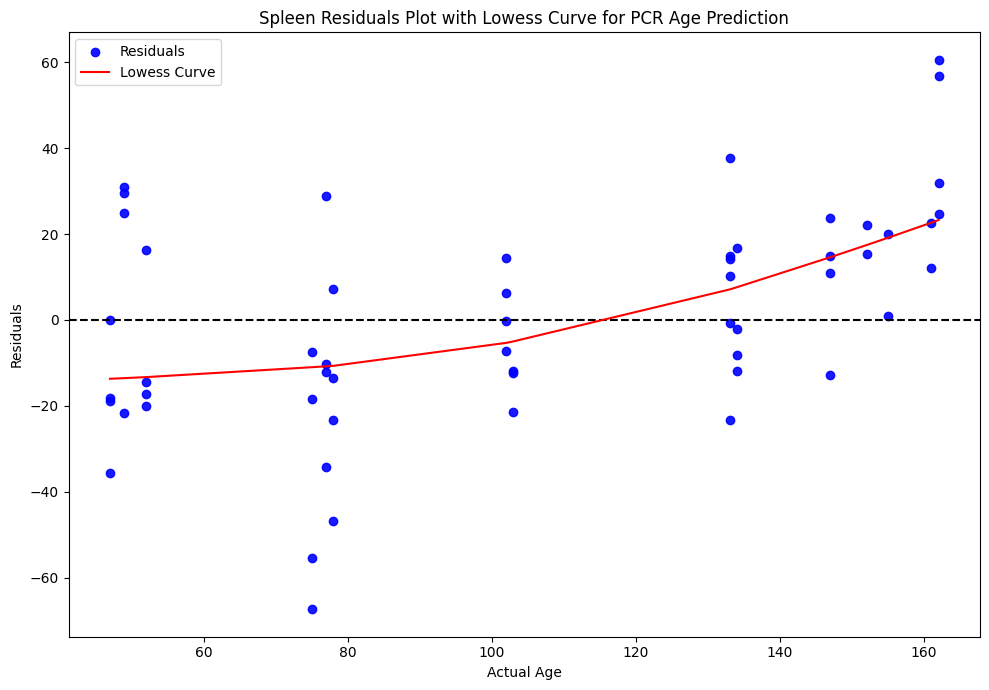

In [53]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Spleen Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

plt.legend()
plt.tight_layout()
plt.show()

# Spinal Cord

In [54]:
spinal_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "SpinalCord"]

spinal_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536,M,SpinalCord,162
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231,M,SpinalCord,103


In [55]:
spinal_df_norm_expression = spinal_df_norm.iloc[:,:-3]

spinal_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,1201.386683,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,1109.762595,169.024683,675.192432,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,1118.631646,170.379150,608.132321,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,916.134914,104.068245,540.820520,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,1066.826277,227.302022,645.405010,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231


In [56]:
spinal_pca_df = spinal_df_norm_expression.copy()

spinal_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,1201.386683,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,1109.762595,169.024683,675.192432,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,1118.631646,170.379150,608.132321,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,916.134914,104.068245,540.820520,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,1066.826277,227.302022,645.405010,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231


In [57]:
spinal_pca_df["age"] = spinal_df_norm["age_days"].tolist()

spinal_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,75
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,169.024683,675.192432,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,52
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,170.379150,608.132321,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,161
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,104.068245,540.820520,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536,162
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,227.302022,645.405010,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231,103


### Run all PCs

In [58]:
metrics_spinal = run_pcr(spinal_pca_df, "Spinalcord")
print(metrics_spinal)

metrics_spinal = run_pcr_leakageSafe(spinal_pca_df, "Spinalcord")
print(metrics_spinal)

[Spinalcord | PCs=1] MAE: 37.6430 | R²: -0.0733 | Pearson: -0.6824
[Spinalcord | PCs=2] MAE: 33.7134 | R²: 0.0673 | Pearson: 0.3020
[Spinalcord | PCs=3] MAE: 22.5653 | R²: 0.4962 | Pearson: 0.7090
[Spinalcord | PCs=4] MAE: 23.5855 | R²: 0.4352 | Pearson: 0.6754
[Spinalcord | PCs=5] MAE: 24.4579 | R²: 0.3987 | Pearson: 0.6551
[Spinalcord | PCs=6] MAE: 22.5409 | R²: 0.4619 | Pearson: 0.6960
[Spinalcord | PCs=7] MAE: 23.3590 | R²: 0.4541 | Pearson: 0.6946
[Spinalcord | PCs=8] MAE: 22.0911 | R²: 0.4870 | Pearson: 0.7163
[Spinalcord | PCs=9] MAE: 22.0203 | R²: 0.4803 | Pearson: 0.7142
[Spinalcord | PCs=10] MAE: 20.5165 | R²: 0.6103 | Pearson: 0.7971
[Spinalcord | PCs=11] MAE: 19.8543 | R²: 0.6047 | Pearson: 0.8037
[Spinalcord | PCs=12] MAE: 19.3325 | R²: 0.6165 | Pearson: 0.8125
[Spinalcord | PCs=13] MAE: 19.8130 | R²: 0.6010 | Pearson: 0.8080
[Spinalcord | PCs=14] MAE: 18.8014 | R²: 0.6535 | Pearson: 0.8285
[Spinalcord | PCs=15] MAE: 19.0469 | R²: 0.6184 | Pearson: 0.8157
[Spinalcord | PCs

### Single PC number

Mean Absolute Error (MAE) with LOOCV and 20 components: 17.35165537526232
R² Score with LOOCV and 20 components: 0.6032386118918576
Pearson Correlation Coefficient with 20 components: 0.8171295433731394


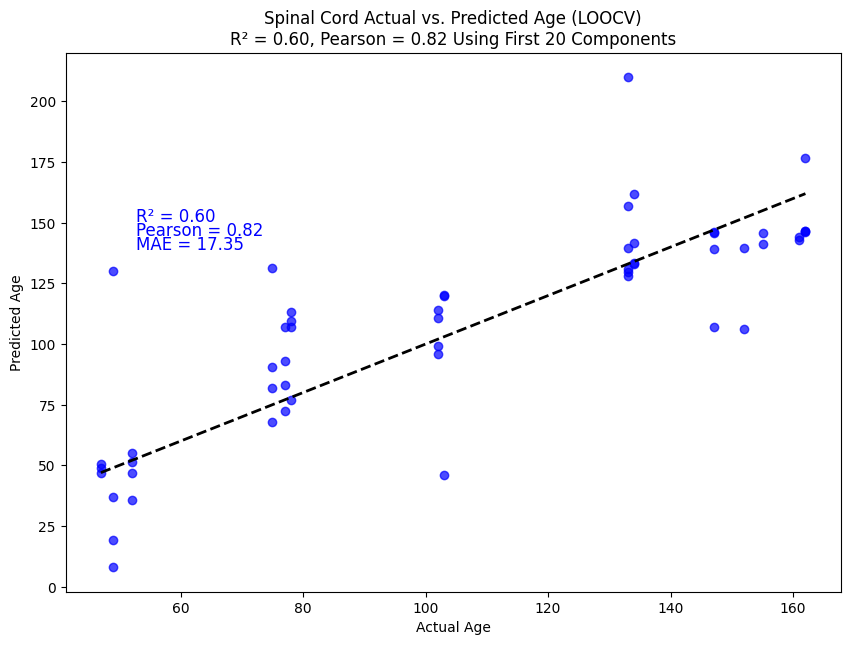

Explained variance by each component (20 components): [0.17680095 0.15196708 0.06487249 0.04186924 0.03645225 0.02716834
 0.02522225 0.02209268 0.02199149 0.01948043 0.017007   0.01526066
 0.01461315 0.01403475 0.01350587 0.01308883 0.01183998 0.01155757
 0.01133177 0.01119523]
Cumulative explained variance (20 components): [0.17680095 0.32876803 0.39364052 0.43550976 0.47196201 0.49913035
 0.5243526  0.54644529 0.56843678 0.58791721 0.6049242  0.62018486
 0.63479802 0.64883276 0.66233863 0.67542746 0.68726743 0.698825
 0.71015677 0.721352  ]


In [59]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = spinal_df_norm['age_days']
X = spinal_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=20, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 20 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 20 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 20 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Spinal Cord Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 20 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (20 components): {explained_variance}')
print(f'Cumulative explained variance (20 components): {cumulative_explained_variance}')

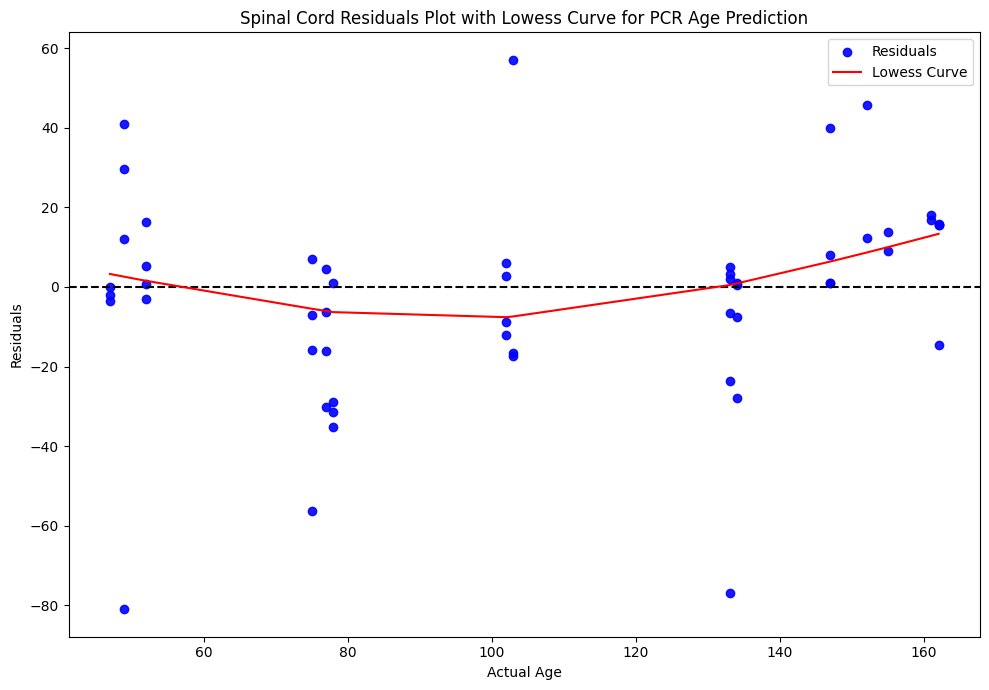

In [60]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Spinal Cord Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Heart

In [61]:
heart_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Heart"]

heart_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,M,Heart,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,M,Heart,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,M,Heart,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,M,Heart,47


In [62]:
heart_df_norm_expression = heart_df_norm.iloc[:,:-3]

heart_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,837.894212,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,948.993808,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,764.407581,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,766.967930,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,651.066933,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187


In [63]:
heart_pca_df = heart_df_norm_expression.copy()

heart_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,837.894212,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,948.993808,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,764.407581,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,766.967930,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,651.066933,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187


In [64]:
heart_pca_df["age"] = heart_df_norm["age_days"].tolist()

heart_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,47


### Run all PCs

In [65]:
metrics_heart = run_pcr(heart_pca_df, "Heart")
print(metrics_heart)

metrics_heart = run_pcr_leakageSafe(spleen_pca_df, "Heart")
print(metrics_heart)

[Heart | PCs=1] MAE: 37.2345 | R²: -0.0506 | Pearson: -0.1196
[Heart | PCs=2] MAE: 35.3790 | R²: 0.0002 | Pearson: 0.1768
[Heart | PCs=3] MAE: 25.6459 | R²: 0.3994 | Pearson: 0.6357
[Heart | PCs=4] MAE: 26.1892 | R²: 0.3822 | Pearson: 0.6250
[Heart | PCs=5] MAE: 26.7952 | R²: 0.3519 | Pearson: 0.6058
[Heart | PCs=6] MAE: 27.3632 | R²: 0.3093 | Pearson: 0.5781
[Heart | PCs=7] MAE: 28.1145 | R²: 0.2622 | Pearson: 0.5491
[Heart | PCs=8] MAE: 25.9536 | R²: 0.0637 | Pearson: 0.5259
[Heart | PCs=9] MAE: 18.8048 | R²: 0.6278 | Pearson: 0.8006
[Heart | PCs=10] MAE: 19.6623 | R²: 0.5852 | Pearson: 0.7782
[Heart | PCs=11] MAE: 15.6799 | R²: 0.6695 | Pearson: 0.8423
[Heart | PCs=12] MAE: 15.0664 | R²: 0.7794 | Pearson: 0.8878
[Heart | PCs=13] MAE: 14.6959 | R²: 0.8166 | Pearson: 0.9058
[Heart | PCs=14] MAE: 12.8882 | R²: 0.8508 | Pearson: 0.9240
[Heart | PCs=15] MAE: 13.0086 | R²: 0.8435 | Pearson: 0.9203
[Heart | PCs=16] MAE: 14.4952 | R²: 0.7826 | Pearson: 0.8953
[Heart | PCs=17] MAE: 14.8317 |

### Single PC number

Mean Absolute Error (MAE) with LOOCV and 15 components: 13.008602446878236
R² Score with LOOCV and 15 components: 0.8435258245502155
Pearson Correlation Coefficient with 15 components: 0.9203094935112799


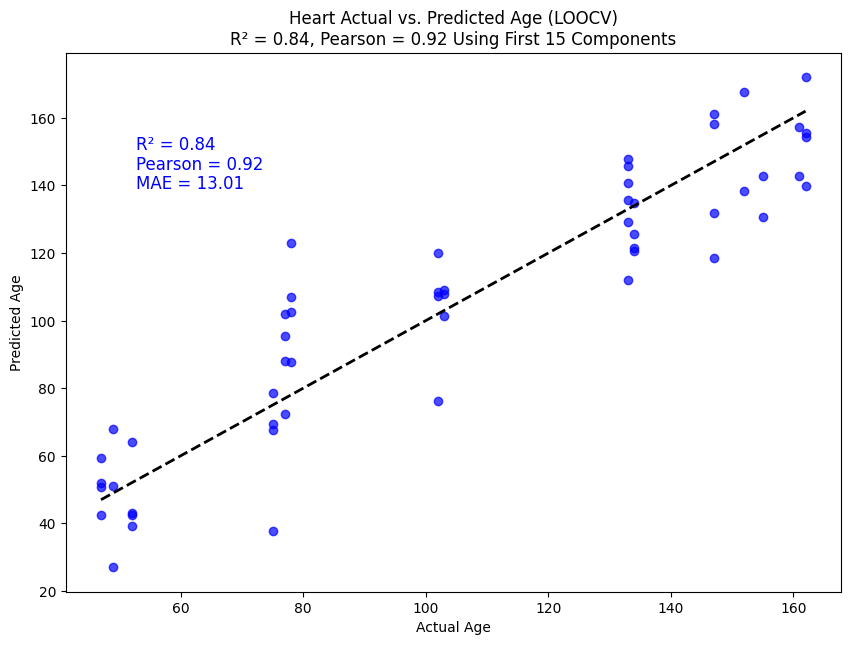

Explained variance by each component (15 components): [0.11697947 0.09287607 0.08642259 0.04427734 0.04367057 0.03682439
 0.03127937 0.0267837  0.02580361 0.02380861 0.0207359  0.01864636
 0.01825212 0.01729327 0.0166072 ]
Cumulative explained variance (15 components): [0.11697947 0.20985555 0.29627814 0.34055547 0.38422604 0.42105043
 0.4523298  0.4791135  0.50491711 0.52872571 0.54946162 0.56810798
 0.5863601  0.60365337 0.62026057]


In [66]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = heart_df_norm['age_days']
X = heart_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=15, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 15 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 15 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 15 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Heart Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 15 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (15 components): {explained_variance}')
print(f'Cumulative explained variance (15 components): {cumulative_explained_variance}')

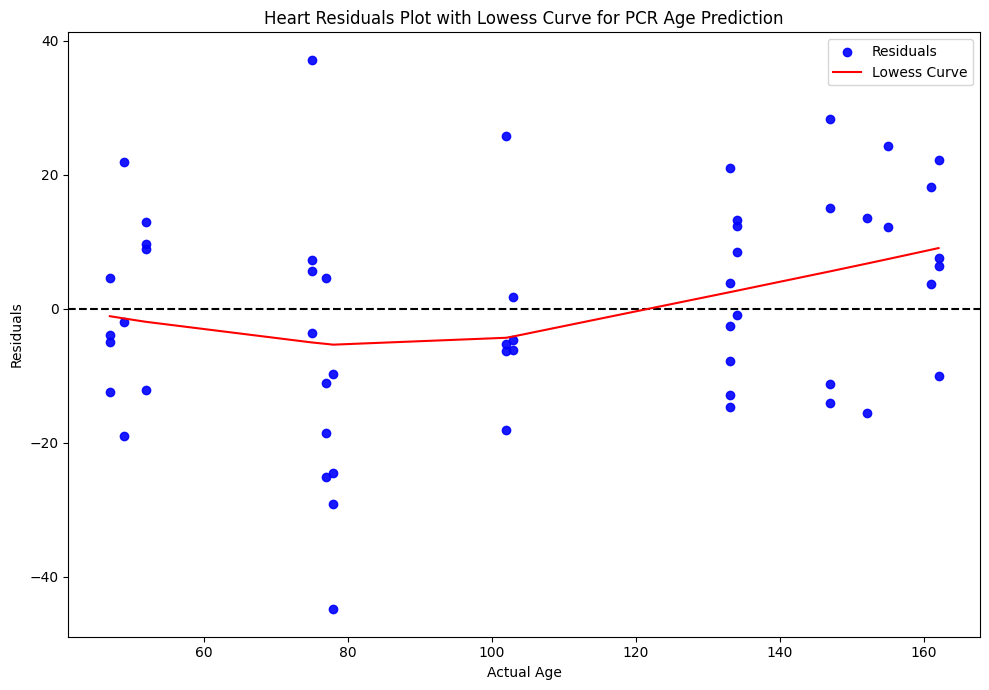

In [67]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Heart Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Skin

In [68]:
skin_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Skin"]

skin_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651,F,Skin,134
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731,M,Skin,161
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184,M,Skin,162
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743,M,Skin,161
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111,F,Skin,155


In [69]:
skin_df_norm_expression = skin_df_norm.iloc[:,:-3]

skin_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,804.272703,104.782007,1523.587021,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,1026.518880,85.140114,1407.714392,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,552.883903,110.282693,1277.808808,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,882.488692,85.079250,1377.116097,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,1063.423318,80.356816,1230.398520,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111


In [70]:
skin_pca_df = skin_df_norm_expression.copy()

skin_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,804.272703,104.782007,1523.587021,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,1026.518880,85.140114,1407.714392,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,552.883903,110.282693,1277.808808,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,882.488692,85.079250,1377.116097,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,1063.423318,80.356816,1230.398520,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111


In [71]:
skin_pca_df["age"] = skin_df_norm["age_days"].tolist()

skin_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,104.782007,1523.587021,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651,134
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,85.140114,1407.714392,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731,161
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,110.282693,1277.808808,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184,162
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,85.079250,1377.116097,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743,161
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,80.356816,1230.398520,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111,155


### Run all PCs

In [72]:
metrics_skin = run_pcr(skin_pca_df, "Skin")
print(metrics_skin)

metrics_skin = run_pcr_leakageSafe(skin_pca_df, "Skin")
print(metrics_skin)

[Skin | PCs=1] MAE: 37.7457 | R²: -0.0719 | Pearson: -0.3536
[Skin | PCs=2] MAE: 27.6852 | R²: 0.3642 | Pearson: 0.6120
[Skin | PCs=3] MAE: 25.5407 | R²: 0.4159 | Pearson: 0.6606
[Skin | PCs=4] MAE: 26.2343 | R²: 0.3182 | Pearson: 0.6288
[Skin | PCs=5] MAE: 26.8375 | R²: 0.2804 | Pearson: 0.6134
[Skin | PCs=6] MAE: 25.9965 | R²: 0.2851 | Pearson: 0.6213
[Skin | PCs=7] MAE: 18.3366 | R²: 0.6883 | Pearson: 0.8370
[Skin | PCs=8] MAE: 18.9072 | R²: 0.6675 | Pearson: 0.8279
[Skin | PCs=9] MAE: 16.5780 | R²: 0.7651 | Pearson: 0.8774
[Skin | PCs=10] MAE: 17.1048 | R²: 0.7422 | Pearson: 0.8673
[Skin | PCs=11] MAE: 17.5361 | R²: 0.6947 | Pearson: 0.8476
[Skin | PCs=12] MAE: 18.5009 | R²: 0.6389 | Pearson: 0.8245
[Skin | PCs=13] MAE: 19.7554 | R²: 0.5873 | Pearson: 0.8045
[Skin | PCs=14] MAE: 20.9504 | R²: 0.5748 | Pearson: 0.8011
[Skin | PCs=15] MAE: 22.1752 | R²: 0.3712 | Pearson: 0.7387
[Skin | PCs=16] MAE: 23.4084 | R²: 0.2827 | Pearson: 0.7162
[Skin | PCs=17] MAE: 22.3923 | R²: 0.3719 | Pea

### Single PC number 

Mean Absolute Error (MAE) with LOOCV and 10 components: 17.104841375520305
R² Score with LOOCV and 10 components: 0.7422458724796654
Pearson Correlation Coefficient with 10 components: 0.867311131538837


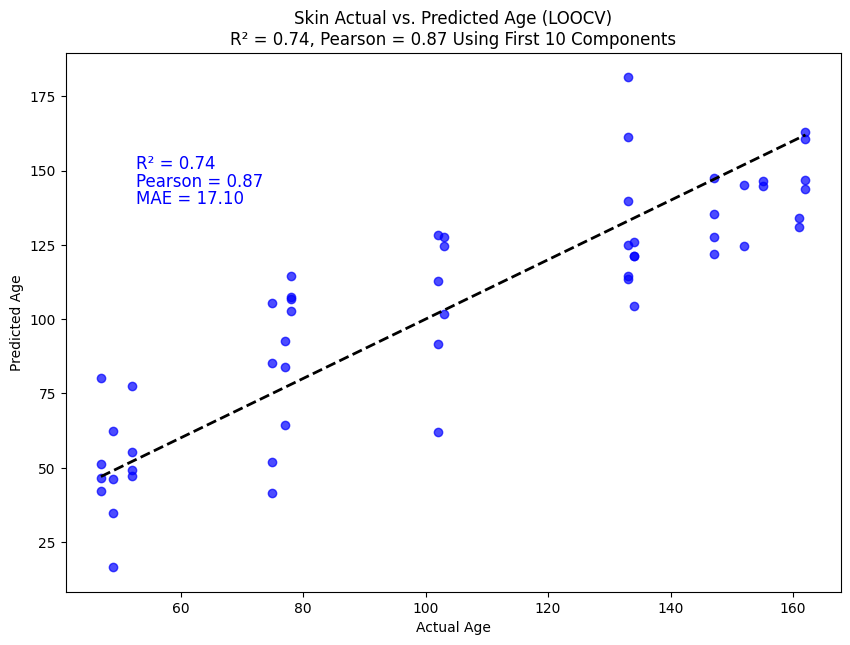

Explained variance by each component (10 components): [0.16870172 0.12118276 0.07486552 0.05045987 0.04324402 0.03746422
 0.03402113 0.02453638 0.0220228  0.0194922 ]
Cumulative explained variance (10 components): [0.16870172 0.28988447 0.36475    0.41520987 0.4584539  0.49591812
 0.52993924 0.55447563 0.57649842 0.59599063]


In [73]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = skin_df_norm['age_days']
X = skin_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=10, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 10 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 10 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 10 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Skin Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 10 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (10 components): {explained_variance}')
print(f'Cumulative explained variance (10 components): {cumulative_explained_variance}')

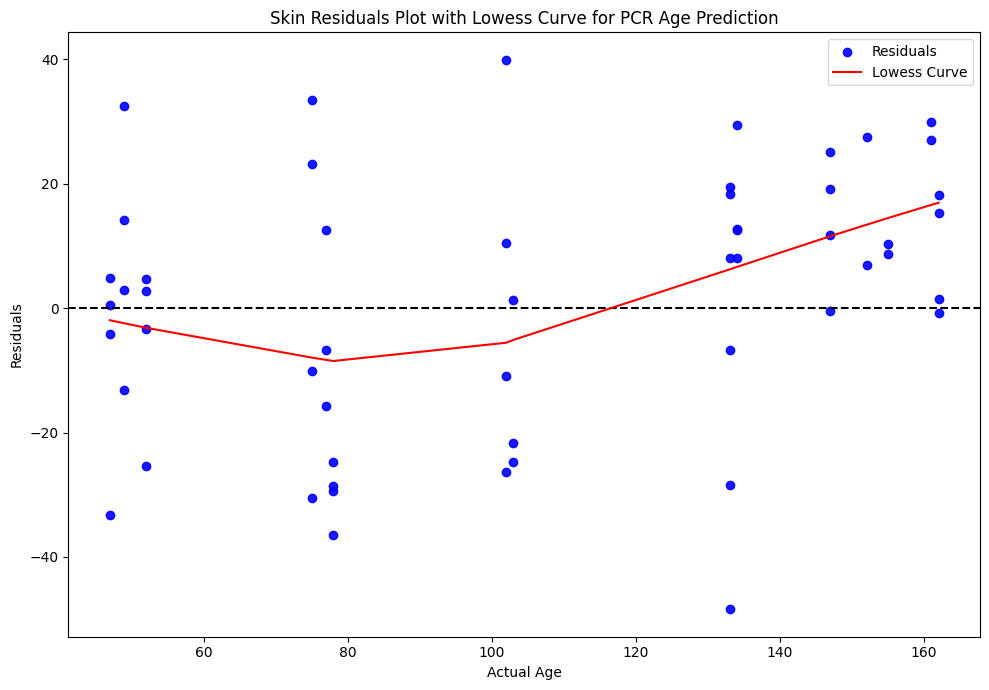

In [74]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Skin Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Brain

In [75]:
brain_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Brain"]

brain_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,M,Brain,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,M,Brain,152
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,F,Brain,78
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,M,Brain,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,M,Brain,162


In [76]:
brain_df_norm_expression = brain_df_norm.iloc[:,:-3]

brain_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,1468.986639,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,1841.111908,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,2283.060869,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,1837.550333,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,1570.372948,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734


In [77]:
brain_pca_df = brain_df_norm_expression.copy()

brain_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,1468.986639,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,1841.111908,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,2283.060869,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,1837.550333,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,1570.372948,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734


In [78]:
brain_pca_df["age"] = brain_df_norm["age_days"].tolist()

brain_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,152
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,78
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,162


### Run all PCs

In [79]:
metrics_brain = run_pcr(brain_pca_df, "Brain")
print(metrics_brain)

metrics_brain = run_pcr_leakageSafe(brain_pca_df, "Brain")
print(metrics_brain)

[Brain | PCs=1] MAE: 35.3296 | R²: 0.0660 | Pearson: 0.2717
[Brain | PCs=2] MAE: 28.2288 | R²: 0.3325 | Pearson: 0.5810
[Brain | PCs=3] MAE: 29.2270 | R²: 0.2877 | Pearson: 0.5551
[Brain | PCs=4] MAE: 29.6628 | R²: 0.2498 | Pearson: 0.5306
[Brain | PCs=5] MAE: 21.2294 | R²: 0.5586 | Pearson: 0.7566
[Brain | PCs=6] MAE: 18.1155 | R²: 0.6423 | Pearson: 0.8069
[Brain | PCs=7] MAE: 18.4855 | R²: 0.6407 | Pearson: 0.8067
[Brain | PCs=8] MAE: 18.1238 | R²: 0.6483 | Pearson: 0.8109
[Brain | PCs=9] MAE: 18.1269 | R²: 0.6458 | Pearson: 0.8100
[Brain | PCs=10] MAE: 16.6675 | R²: 0.7196 | Pearson: 0.8519
[Brain | PCs=11] MAE: 15.2995 | R²: 0.7500 | Pearson: 0.8695
[Brain | PCs=12] MAE: 16.3363 | R²: 0.7244 | Pearson: 0.8555
[Brain | PCs=13] MAE: 16.1967 | R²: 0.7189 | Pearson: 0.8528
[Brain | PCs=14] MAE: 16.9884 | R²: 0.6892 | Pearson: 0.8410
[Brain | PCs=15] MAE: 16.8161 | R²: 0.7317 | Pearson: 0.8636
[Brain | PCs=16] MAE: 17.7699 | R²: 0.6470 | Pearson: 0.8248
[Brain | PCs=17] MAE: 18.3230 | R

### Single PC number

Mean Absolute Error (MAE) with LOOCV and 15 components: 16.816133663102434
R² Score with LOOCV and 15 components: 0.7317207587594776
Pearson Correlation Coefficient with 15 components: 0.863602873388164


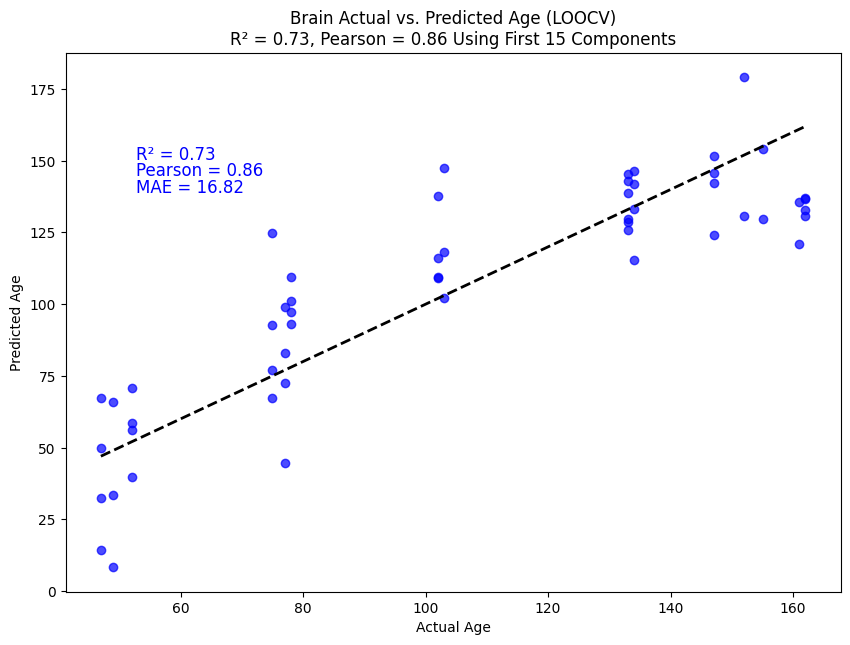

Explained variance by each component (15 components): [0.14070172 0.08769443 0.07262345 0.06357036 0.05270536 0.03974927
 0.02823477 0.02508201 0.02265126 0.0190357  0.01814894 0.01594042
 0.0157187  0.01480547 0.01440136]
Cumulative explained variance (15 components): [0.14070172 0.22839615 0.3010196  0.36458997 0.41729532 0.45704459
 0.48527936 0.51036137 0.53301263 0.55204834 0.57019727 0.58613769
 0.60185639 0.61666187 0.63106322]


In [80]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = brain_df_norm['age_days']
X = brain_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=15, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 15 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 15 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 15 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Brain Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 15 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (15 components): {explained_variance}')
print(f'Cumulative explained variance (15 components): {cumulative_explained_variance}')

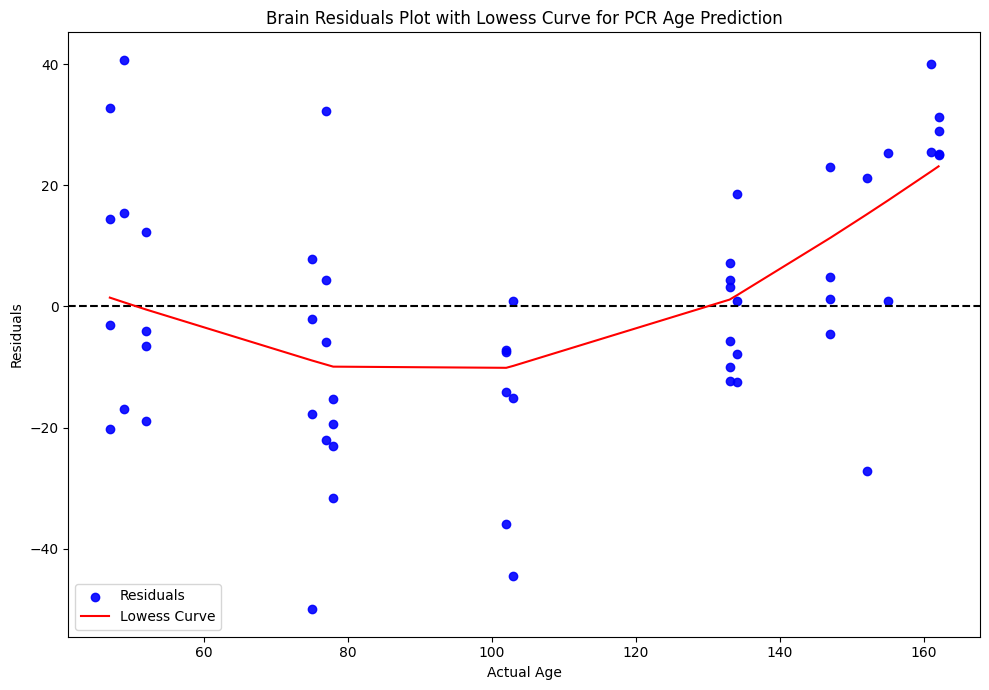

In [81]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Brain Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Liver

In [82]:
liver_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Liver"]

liver_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,M,Liver,134
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,F,Liver,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,F,Liver,133
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,M,Liver,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,F,Liver,102


In [83]:
liver_df_norm_expression = liver_df_norm.iloc[:,:-3]

liver_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,228.349557,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,181.117195,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,140.536893,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,184.151765,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,118.498749,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056


In [84]:
liver_pca_df = liver_df_norm_expression.copy()

liver_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,228.349557,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,181.117195,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,140.536893,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,184.151765,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,118.498749,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056


In [85]:
liver_pca_df["age"] = liver_df_norm["age_days"].tolist()

liver_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,134
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,133
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,102


### Run all PCs

In [86]:
metrics_liver = run_pcr(liver_pca_df, "Liver")
print(metrics_liver)

metrics_liver = run_pcr_leakageSafe(liver_pca_df, "Liver")
print(metrics_liver)

[Liver | PCs=1] MAE: 36.8750 | R²: -0.0302 | Pearson: 0.0391
[Liver | PCs=2] MAE: 37.6887 | R²: -0.0661 | Pearson: 0.0101
[Liver | PCs=3] MAE: 32.6498 | R²: 0.1047 | Pearson: 0.3642
[Liver | PCs=4] MAE: 31.8848 | R²: 0.1439 | Pearson: 0.4165
[Liver | PCs=5] MAE: 32.6723 | R²: 0.0992 | Pearson: 0.3861
[Liver | PCs=6] MAE: 24.2743 | R²: 0.4614 | Pearson: 0.6877
[Liver | PCs=7] MAE: 24.9860 | R²: 0.4302 | Pearson: 0.6693
[Liver | PCs=8] MAE: 25.6260 | R²: 0.4086 | Pearson: 0.6578
[Liver | PCs=9] MAE: 23.3579 | R²: 0.5467 | Pearson: 0.7484
[Liver | PCs=10] MAE: 25.9040 | R²: 0.4585 | Pearson: 0.7095
[Liver | PCs=11] MAE: 20.1673 | R²: 0.6377 | Pearson: 0.8172
[Liver | PCs=12] MAE: 20.7518 | R²: 0.6124 | Pearson: 0.8056
[Liver | PCs=13] MAE: 21.4724 | R²: 0.5329 | Pearson: 0.7840
[Liver | PCs=14] MAE: 23.5762 | R²: 0.3433 | Pearson: 0.7388
[Liver | PCs=15] MAE: 24.3222 | R²: 0.3644 | Pearson: 0.7140
[Liver | PCs=16] MAE: 22.9082 | R²: 0.2967 | Pearson: 0.7400
[Liver | PCs=17] MAE: 20.9376 |

### Single PC number 

In [87]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = liver_df_norm['age_days']
X = liver_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

Mean Absolute Error (MAE) with LOOCV and 10 components: 25.903957197891888
R² Score with LOOCV and 10 components: 0.4585051913614151
Pearson Correlation Coefficient with 10 components: 0.7095404612119807


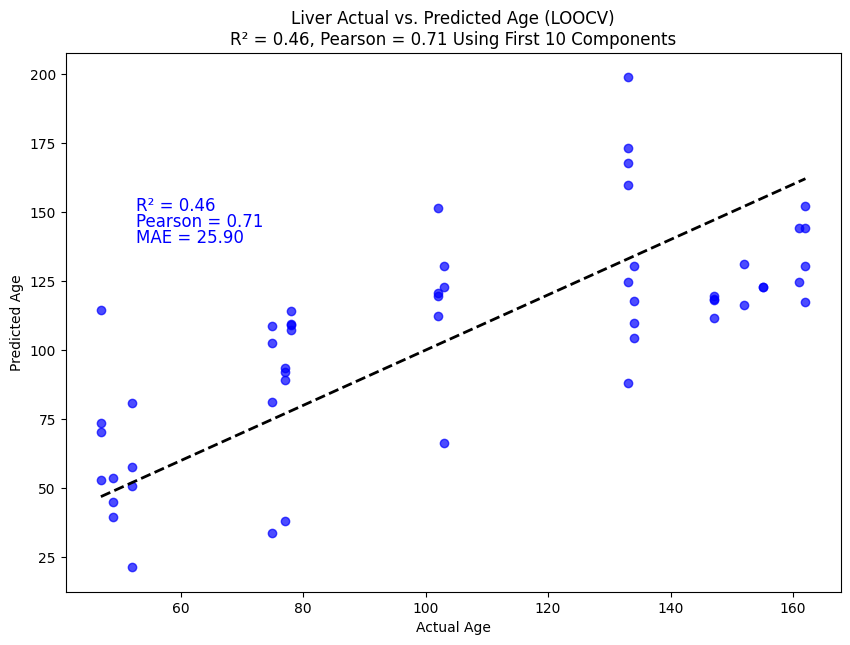

Explained variance by each component (10 components): [0.1622096  0.10016464 0.06931238 0.04646262 0.03715893 0.03142333
 0.02492292 0.02138951 0.01911738 0.01812304]
Cumulative explained variance (10 components): [0.1622096  0.26237424 0.33168662 0.37814924 0.41530817 0.44673149
 0.47165441 0.49304392 0.5121613  0.53028435]


In [88]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=10, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 10 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 10 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 10 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Liver Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 10 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (10 components): {explained_variance}')
print(f'Cumulative explained variance (10 components): {cumulative_explained_variance}')

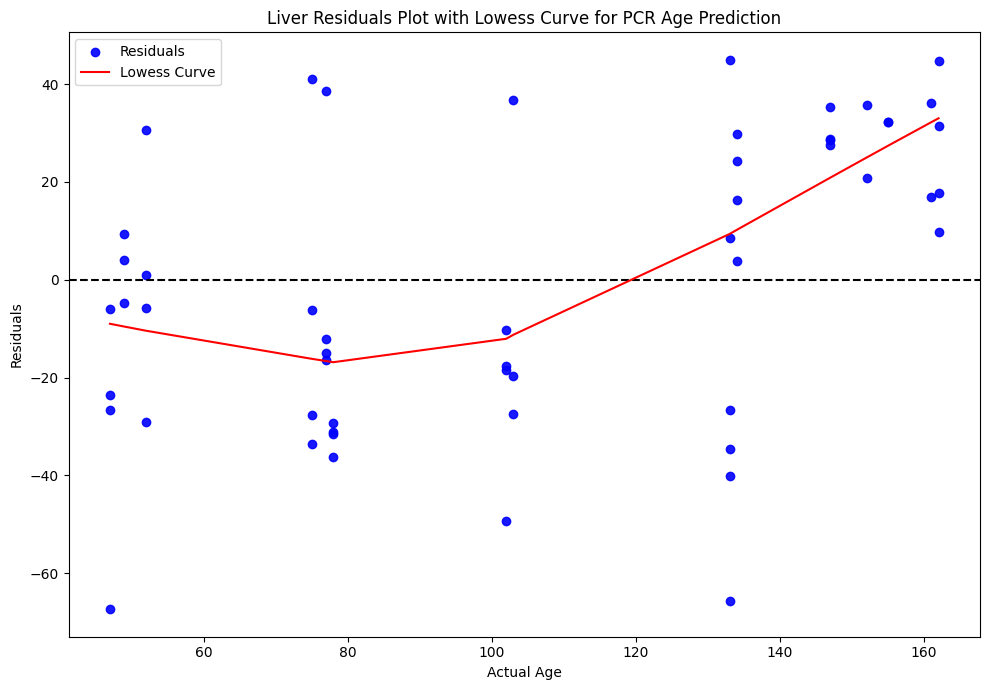

In [89]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Liver Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Fat

In [90]:
fat_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Fat"]

fat_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,M,Fat,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,M,Fat,77
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,F,Fat,78
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,M,Fat,103
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,F,Fat,134


In [91]:
fat_df_norm_expression = fat_df_norm.iloc[:,:-3]

fat_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,301.647333,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,407.861536,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,240.468126,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,250.358741,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,321.552132,105.029591,1095.539424,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530


In [92]:
fat_pca_df = fat_df_norm_expression.copy()

fat_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,301.647333,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,407.861536,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,240.468126,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,250.358741,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,321.552132,105.029591,1095.539424,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530


In [93]:
fat_pca_df["age"] = fat_df_norm["age_days"].tolist()

fat_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,78
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,103
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,105.029591,1095.539424,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,134


### Run all PCs

In [94]:
metrics_fat = run_pcr(fat_pca_df, "Fat")
print(metrics_fat)

metrics_Fat = run_pcr_leakageSafe(fat_pca_df, "Fat")
print(metrics_Fat)

[Fat | PCs=1] MAE: 38.4213 | R²: -0.0709 | Pearson: -0.2302
[Fat | PCs=2] MAE: 27.0316 | R²: 0.4324 | Pearson: 0.6607
[Fat | PCs=3] MAE: 28.0329 | R²: 0.3694 | Pearson: 0.6255
[Fat | PCs=4] MAE: 24.2981 | R²: 0.5132 | Pearson: 0.7207
[Fat | PCs=5] MAE: 24.2170 | R²: 0.5003 | Pearson: 0.7128
[Fat | PCs=6] MAE: 22.8983 | R²: 0.5712 | Pearson: 0.7612
[Fat | PCs=7] MAE: 23.7705 | R²: 0.5482 | Pearson: 0.7485
[Fat | PCs=8] MAE: 24.4589 | R²: 0.5199 | Pearson: 0.7338
[Fat | PCs=9] MAE: 25.5606 | R²: 0.3609 | Pearson: 0.6624
[Fat | PCs=10] MAE: 26.5465 | R²: 0.2960 | Pearson: 0.6316
[Fat | PCs=11] MAE: 26.1620 | R²: 0.2377 | Pearson: 0.6211
[Fat | PCs=12] MAE: 27.5443 | R²: 0.0673 | Pearson: 0.5780
[Fat | PCs=13] MAE: 28.7096 | R²: -0.0807 | Pearson: 0.5681
[Fat | PCs=14] MAE: 31.1526 | R²: -0.9098 | Pearson: 0.4177
[Fat | PCs=15] MAE: 24.5108 | R²: 0.1050 | Pearson: 0.6226
[Fat | PCs=16] MAE: 23.3077 | R²: 0.2701 | Pearson: 0.6841
[Fat | PCs=17] MAE: 20.0495 | R²: 0.5558 | Pearson: 0.7887
[F

### Single PC number

In [95]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = fat_df_norm['age_days']
X = fat_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

Mean Absolute Error (MAE) with LOOCV and 20 components: 23.393802728184756
R² Score with LOOCV and 20 components: 0.1162720058474016
Pearson Correlation Coefficient with 10 components: 0.6619808625762407


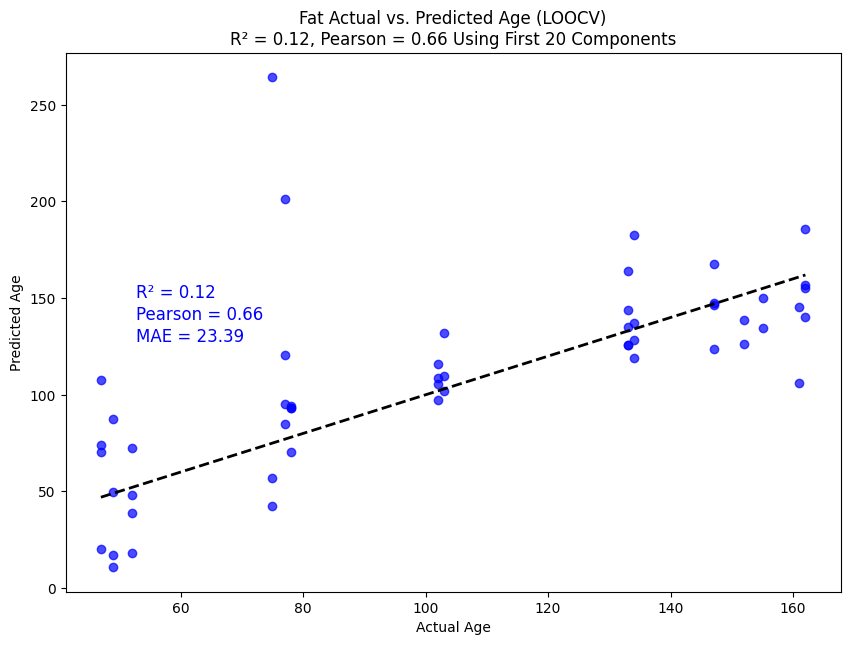

Explained variance by each component (20 components): [0.21643091 0.09295229 0.06697687 0.05374036 0.05089624 0.0371777
 0.02516601 0.02372619 0.02200397 0.02059564 0.01797212 0.01713574
 0.01582574 0.0150482  0.01462095 0.01349064 0.01340829 0.01266266
 0.01246053 0.01118276]
Cumulative explained variance (20 components): [0.21643091 0.30938319 0.37636006 0.43010042 0.48099666 0.51817437
 0.54334038 0.56706657 0.58907054 0.60966618 0.6276383  0.64477404
 0.66059978 0.67564798 0.69026892 0.70375957 0.71716786 0.72983051
 0.74229105 0.75347381]


In [96]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=20, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 20 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 20 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 10 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Fat Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 20 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.3 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (20 components): {explained_variance}')
print(f'Cumulative explained variance (20 components): {cumulative_explained_variance}')

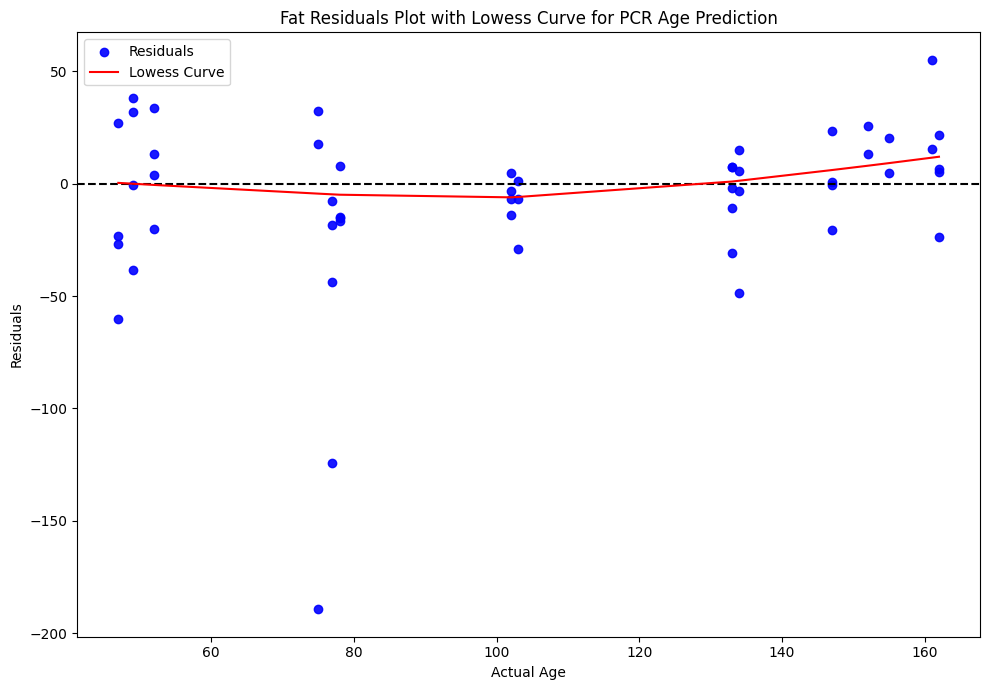

In [97]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Fat Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Bone

In [98]:
bone_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Bone"]

bone_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538,M,Bone,133
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632,F,Bone,102
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785,M,Bone,77
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032,M,Bone,134


In [99]:
bone_df_norm_expression = bone_df_norm.iloc[:,:-3]

bone_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,774.447946,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,898.878807,73.266277,598.159012,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,419.148629,131.822639,958.279540,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,435.560231,50.715917,875.098182,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,702.026403,111.741227,947.371270,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032


In [100]:
bone_pca_df = bone_df_norm_expression.copy()

bone_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,774.447946,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,898.878807,73.266277,598.159012,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,419.148629,131.822639,958.279540,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,435.560231,50.715917,875.098182,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,702.026403,111.741227,947.371270,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032


In [101]:
bone_pca_df["age"] = bone_df_norm["age_days"].tolist()

bone_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,78
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,73.266277,598.159012,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538,133
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,131.822639,958.279540,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632,102
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,50.715917,875.098182,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785,77
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,111.741227,947.371270,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032,134


### Run all PCs

In [102]:
metrics_bone = run_pcr(bone_pca_df, "Bone")
print(metrics_bone)

metrics_bone = run_pcr_leakageSafe(bone_pca_df, "Bone")
print(metrics_bone)

[Bone | PCs=1] MAE: 37.7026 | R²: -0.0207 | Pearson: 0.0762
[Bone | PCs=2] MAE: 38.0914 | R²: -0.0614 | Pearson: 0.0054
[Bone | PCs=3] MAE: 38.0451 | R²: -0.0830 | Pearson: 0.0248
[Bone | PCs=4] MAE: 35.2836 | R²: 0.0407 | Pearson: 0.2795
[Bone | PCs=5] MAE: 35.7784 | R²: 0.0008 | Pearson: 0.2531
[Bone | PCs=6] MAE: 35.1711 | R²: 0.0035 | Pearson: 0.2930
[Bone | PCs=7] MAE: 34.7467 | R²: 0.0065 | Pearson: 0.3027
[Bone | PCs=8] MAE: 30.1868 | R²: 0.2365 | Pearson: 0.5261
[Bone | PCs=9] MAE: 28.4190 | R²: 0.3014 | Pearson: 0.5869
[Bone | PCs=10] MAE: 29.5449 | R²: 0.2206 | Pearson: 0.5658
[Bone | PCs=11] MAE: 29.9187 | R²: 0.1804 | Pearson: 0.5526
[Bone | PCs=12] MAE: 27.9624 | R²: 0.2633 | Pearson: 0.6279
[Bone | PCs=13] MAE: 31.0074 | R²: 0.0987 | Pearson: 0.6000
[Bone | PCs=14] MAE: 32.3022 | R²: -0.0362 | Pearson: 0.5751
[Bone | PCs=15] MAE: 33.4048 | R²: -0.1164 | Pearson: 0.5496
[Bone | PCs=16] MAE: 35.3829 | R²: -0.3008 | Pearson: 0.5300
[Bone | PCs=17] MAE: 36.9139 | R²: -0.7194 

### Single PC number

In [103]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = bone_df_norm['age_days']
X = bone_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

Mean Absolute Error (MAE) with LOOCV and 10 components: 29.544933862566776
R² Score with LOOCV and 10 components: 0.22062628242516313
Pearson Correlation Coefficient with 10 components: 0.5657838427087185


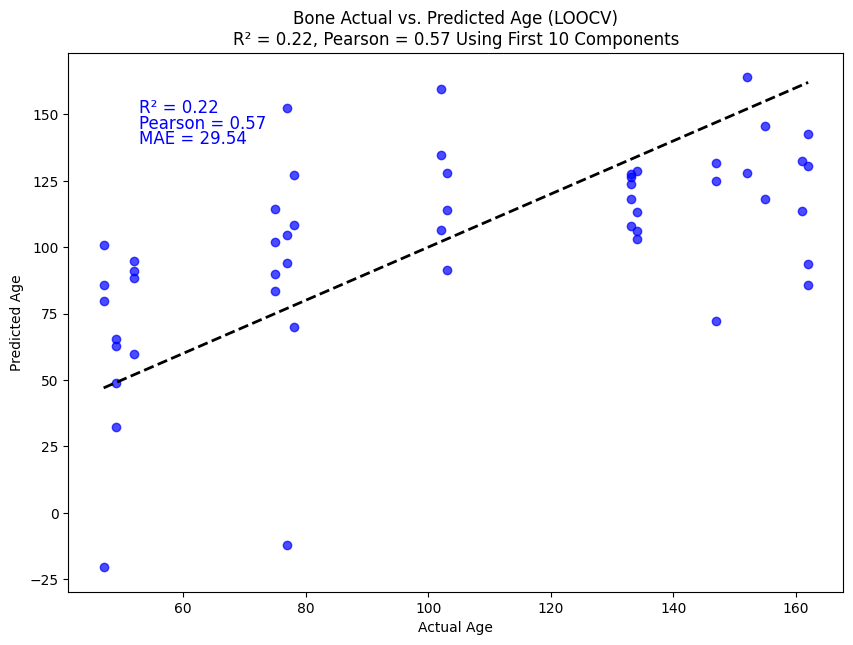

Explained variance by each component (10 components): [0.13856912 0.10843678 0.07987781 0.06290994 0.05023941 0.04764681
 0.0356047  0.03262692 0.02983498 0.02675892]
Cumulative explained variance (10 components): [0.13856912 0.2470059  0.32688371 0.38979365 0.44003306 0.48767987
 0.52328458 0.55591149 0.58574648 0.6125054 ]


In [104]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=10, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 10 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 10 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 10 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Bone Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 10 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (10 components): {explained_variance}')
print(f'Cumulative explained variance (10 components): {cumulative_explained_variance}')

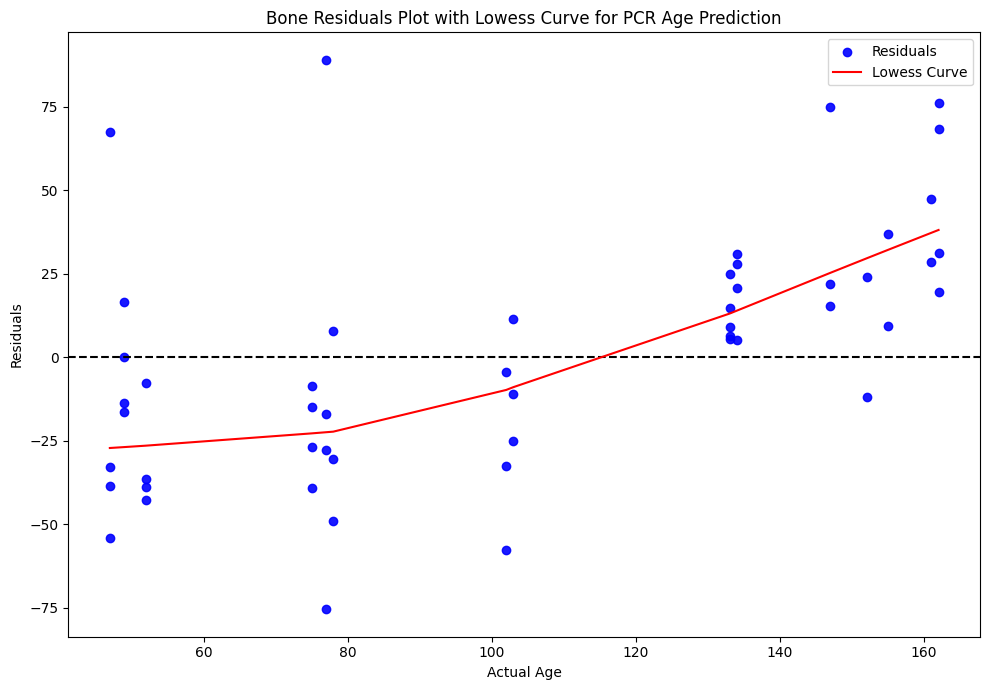

In [105]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Bone Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Eye

In [106]:
eye_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Eye"]

eye_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630,M,Eye,47
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132,M,Eye,147
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668,M,Eye,78
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675,F,Eye,103
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592,F,Eye,78


In [107]:
eye_df_norm_expression = eye_df_norm.iloc[:,:-3]

eye_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,1033.337260,295.577020,1254.428871,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,1093.682719,266.578828,969.008971,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,623.307091,353.932127,756.182633,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,1175.747049,297.783510,912.357987,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,1066.402181,305.006723,1040.611171,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592


In [108]:
eye_pca_df = eye_df_norm_expression.copy()

eye_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,1033.337260,295.577020,1254.428871,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,1093.682719,266.578828,969.008971,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,623.307091,353.932127,756.182633,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,1175.747049,297.783510,912.357987,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,1066.402181,305.006723,1040.611171,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592


In [109]:
eye_pca_df["age"] = eye_df_norm["age_days"].tolist()

eye_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,295.577020,1254.428871,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630,47
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,266.578828,969.008971,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132,147
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,353.932127,756.182633,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668,78
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,297.783510,912.357987,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675,103
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,305.006723,1040.611171,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592,78


### Run all PCs

In [110]:
metrics_eye = run_pcr(eye_pca_df, "Eye")
print(metrics_eye)

metrics_eye = run_pcr_leakageSafe(eye_pca_df, "Eye")
print(metrics_eye)

[Eye | PCs=1] MAE: 26.4431 | R²: 0.3223 | Pearson: 0.5713
[Eye | PCs=2] MAE: 27.3639 | R²: 0.2946 | Pearson: 0.5608
[Eye | PCs=3] MAE: 28.6255 | R²: 0.0630 | Pearson: 0.4724
[Eye | PCs=4] MAE: 28.5644 | R²: 0.0241 | Pearson: 0.4740
[Eye | PCs=5] MAE: 29.3076 | R²: -0.0458 | Pearson: 0.4474
[Eye | PCs=6] MAE: 28.6536 | R²: -0.0139 | Pearson: 0.4554
[Eye | PCs=7] MAE: 29.6529 | R²: -0.0700 | Pearson: 0.4703
[Eye | PCs=8] MAE: 24.8195 | R²: 0.2931 | Pearson: 0.6489
[Eye | PCs=9] MAE: 19.9716 | R²: 0.4578 | Pearson: 0.7236
[Eye | PCs=10] MAE: 20.8789 | R²: 0.3566 | Pearson: 0.6872
[Eye | PCs=11] MAE: 27.6630 | R²: -0.3405 | Pearson: 0.5239
[Eye | PCs=12] MAE: 33.5459 | R²: -1.1154 | Pearson: 0.3719
[Eye | PCs=13] MAE: 35.7512 | R²: -1.5203 | Pearson: 0.3078
[Eye | PCs=14] MAE: 25.8227 | R²: -0.2602 | Pearson: 0.5202
[Eye | PCs=15] MAE: 32.0516 | R²: -1.3301 | Pearson: 0.3094
[Eye | PCs=16] MAE: 32.5865 | R²: -1.3333 | Pearson: 0.3125
[Eye | PCs=17] MAE: 36.1495 | R²: -2.3902 | Pearson: 0.2

### Single PC number

In [111]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = eye_df_norm['age_days']
X = eye_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

Mean Absolute Error (MAE) with LOOCV and 10 components: 20.87894319007924
R² Score with LOOCV and 10 components: 0.35656502483878305
Pearson Correlation Coefficient with 10 components: 0.6871883842561698


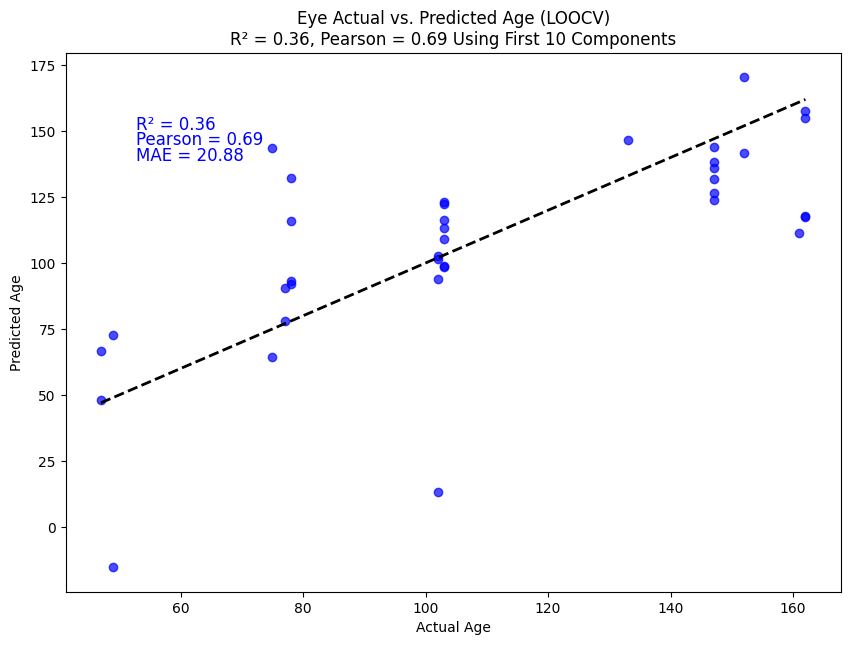

Explained variance by each component (10 components): [0.20936455 0.12841959 0.08903997 0.05259322 0.04692429 0.03695803
 0.03044902 0.02824342 0.02580385 0.02264044]
Cumulative explained variance (10 components): [0.20936455 0.33778414 0.42682412 0.47941734 0.52634163 0.56329966
 0.59374868 0.6219921  0.64779595 0.67043639]


In [112]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=10, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 10 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 10 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 10 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Eye Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 10 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.15 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (10 components): {explained_variance}')
print(f'Cumulative explained variance (10 components): {cumulative_explained_variance}')

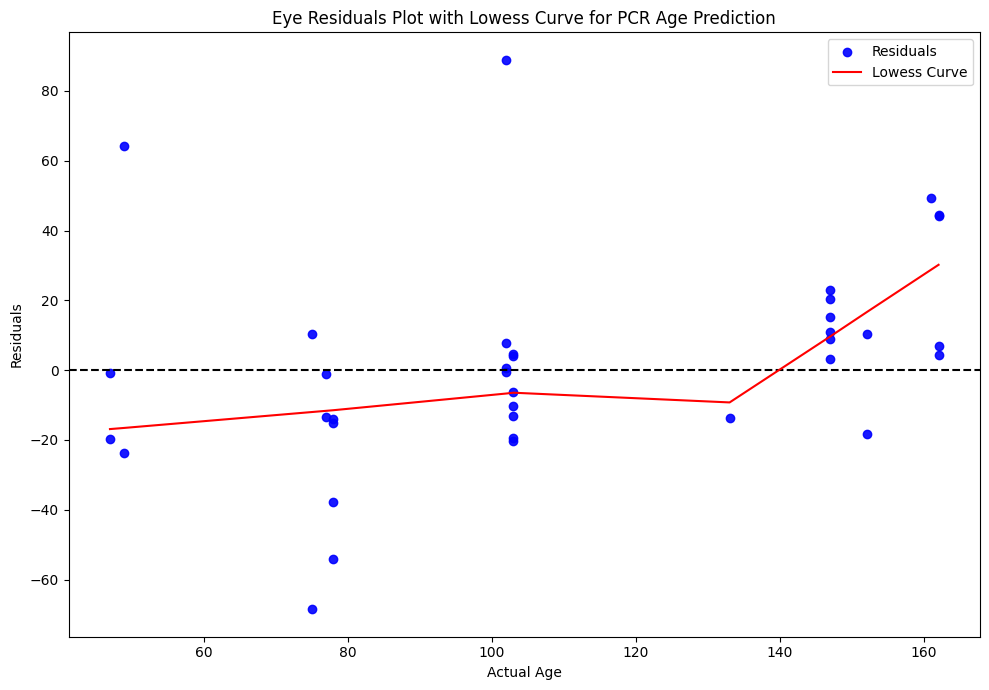

In [113]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Eye Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Testis

In [114]:
testis_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Testis"]

testis_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872,M,Testis,78
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021,M,Testis,75
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754,M,Testis,133
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915,M,Testis,162
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379,M,Testis,134


In [115]:
testis_df_norm_expression = testis_df_norm.iloc[:,:-3]

testis_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,193.829539,797.005376,2551.637109,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,230.508856,541.005012,2004.045449,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,255.317210,670.878555,2646.711739,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,235.348929,856.049400,2102.622848,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,240.724872,749.844142,2418.316532,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379


In [116]:
testis_pca_df = testis_df_norm_expression.copy()

testis_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,193.829539,797.005376,2551.637109,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,230.508856,541.005012,2004.045449,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,255.317210,670.878555,2646.711739,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,235.348929,856.049400,2102.622848,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,240.724872,749.844142,2418.316532,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379


In [117]:
testis_pca_df["age"] = testis_df_norm["age_days"].tolist()

testis_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,797.005376,2551.637109,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872,78
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,541.005012,2004.045449,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021,75
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,670.878555,2646.711739,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754,133
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,856.049400,2102.622848,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915,162
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,749.844142,2418.316532,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379,134


### Run all PCs

In [118]:
metrics_testis = run_pcr(testis_pca_df, "Testis")
print(metrics_testis)

metrics_testis = run_pcr_leakageSafe(testis_pca_df, "Testis")
print(metrics_testis)

[Testis | PCs=1] MAE: 39.5020 | R²: -0.0874 | Pearson: -0.0737
[Testis | PCs=2] MAE: 38.4327 | R²: -0.0259 | Pearson: 0.1961
[Testis | PCs=3] MAE: 34.5073 | R²: 0.0942 | Pearson: 0.3883
[Testis | PCs=4] MAE: 21.3839 | R²: 0.6158 | Pearson: 0.7878
[Testis | PCs=5] MAE: 21.2053 | R²: 0.5664 | Pearson: 0.7608
[Testis | PCs=6] MAE: 22.4730 | R²: 0.5125 | Pearson: 0.7391
[Testis | PCs=7] MAE: 18.5950 | R²: 0.5542 | Pearson: 0.8266
[Testis | PCs=8] MAE: 16.0874 | R²: 0.6210 | Pearson: 0.8528
[Testis | PCs=9] MAE: 17.6310 | R²: 0.5599 | Pearson: 0.8261
[Testis | PCs=10] MAE: 24.0069 | R²: -0.1226 | Pearson: 0.7394
[Testis | PCs=11] MAE: 20.5221 | R²: 0.3653 | Pearson: 0.8241
[Testis | PCs=12] MAE: 16.3542 | R²: 0.6709 | Pearson: 0.8817
[Testis | PCs=13] MAE: 17.0154 | R²: 0.5915 | Pearson: 0.8663
[Testis | PCs=14] MAE: 18.7564 | R²: 0.4960 | Pearson: 0.8562
[Testis | PCs=15] MAE: 18.9187 | R²: 0.4520 | Pearson: 0.8396
[Testis | PCs=16] MAE: 17.2554 | R²: 0.5945 | Pearson: 0.8682
[Testis | PCs

### Single PC number

In [119]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = testis_df_norm['age_days']
X = testis_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

Mean Absolute Error (MAE) with LOOCV and 15 components: 18.91870558035934
R² Score with LOOCV and 15 components: 0.4520343009961131
Pearson Correlation Coefficient with 15 components: 0.839628464845087


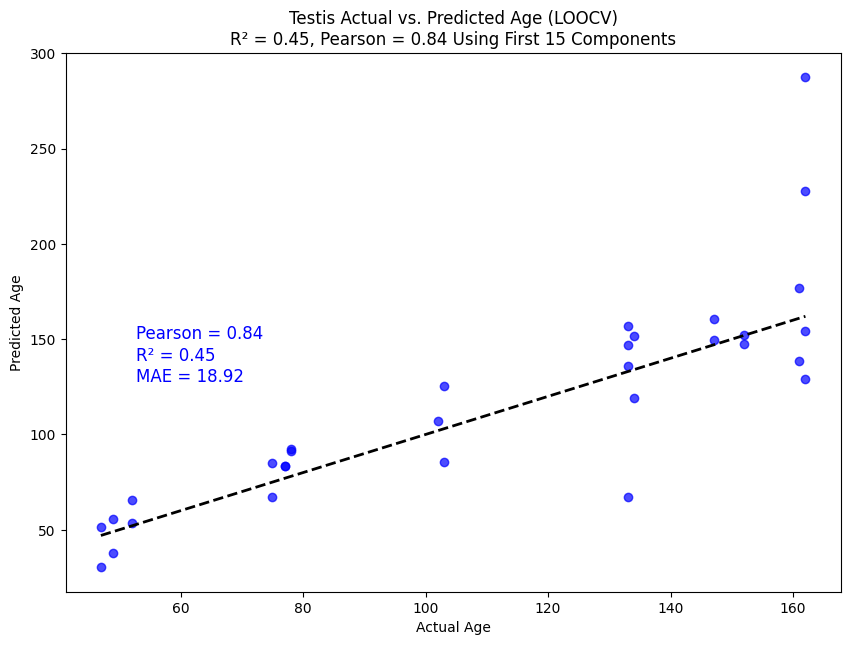

Explained variance by each component (15 components): [0.13656633 0.08975743 0.08363682 0.05004766 0.04915457 0.03928055
 0.03672488 0.03411844 0.03077803 0.0280543  0.02702869 0.02651345
 0.0260216  0.02443027 0.02395249]
Cumulative explained variance (15 components): [0.13656633 0.22632376 0.30996058 0.36000824 0.40916281 0.44844336
 0.48516824 0.51928669 0.55006472 0.57811902 0.60514772 0.63166117
 0.65768277 0.68211304 0.70606553]


In [120]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=15, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 15 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 15 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 15 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Testis Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 15 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.3 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (15 components): {explained_variance}')
print(f'Cumulative explained variance (15 components): {cumulative_explained_variance}')

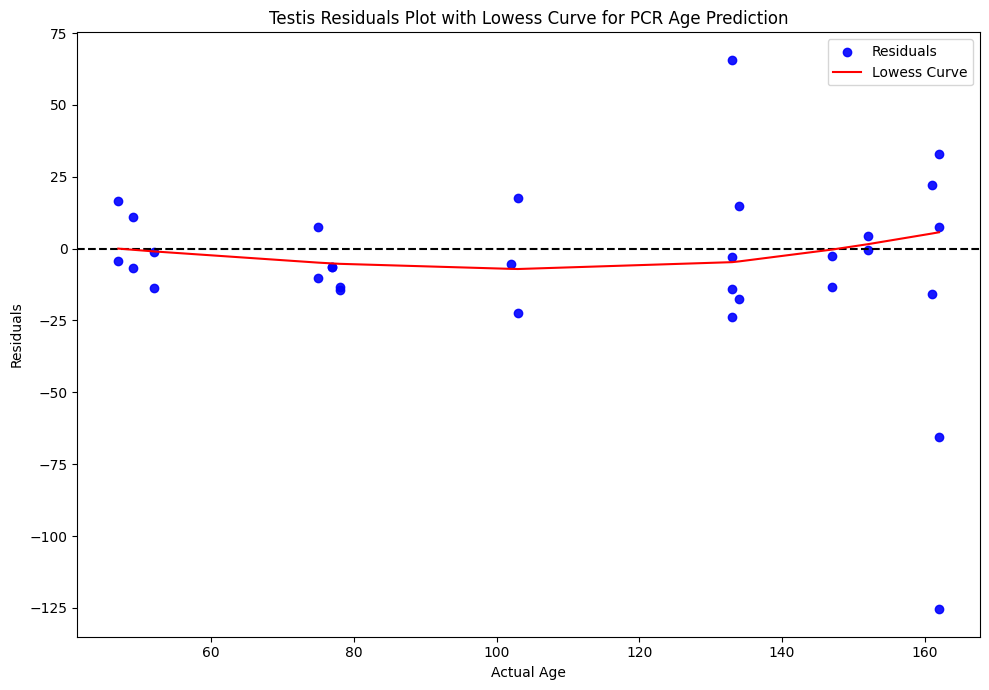

In [121]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Testis Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()

# Ovary

In [122]:
ovary_df_norm = df_norm_metadata.loc[df_norm_metadata.iloc[:,-2] == "Ovary"]

ovary_df_norm.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A23_1,27.012859,1133.939803,453.215750,226.307732,517.446326,841.600637,1213.177523,267.127164,1103.925515,486.831752,...,203.496873,1713.815848,447.212892,564.868901,4106.554892,321.753168,1279.208957,F,Ovary,78
B21_1,20.475689,1021.327380,437.360722,222.775499,488.959459,787.085495,1417.736724,405.418647,1060.640703,378.390737,...,171.176762,1375.147290,443.093915,438.179750,4603.753971,484.864321,1013.137104,F,Ovary,155
B24_1,39.057682,902.808709,557.692472,232.425221,511.591602,533.361457,1333.723788,291.331888,915.614506,449.483485,...,170.317104,1703.171040,416.188412,565.375950,4901.418913,508.390152,1235.119149,F,Ovary,75
C23_1,26.677866,1058.222034,417.953240,215.848192,462.416351,880.369592,1059.838875,370.256449,1092.175682,515.772084,...,229.591335,1485.876317,486.668957,425.229022,3709.031851,392.892214,1054.988353,F,Ovary,147
D21_1,48.765093,940.469648,580.536820,212.089452,515.516696,990.008790,1332.912538,223.700188,1429.668675,535.641972,...,252.340004,1655.691010,517.838843,601.436145,4955.462295,421.082707,1150.236952,F,Ovary,78


In [123]:
ovary_df_norm_expression = ovary_df_norm.iloc[:,:-3]

ovary_df_norm_expression.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A23_1,27.012859,1133.939803,453.215750,226.307732,517.446326,841.600637,1213.177523,267.127164,1103.925515,486.831752,...,453.816035,106.850865,1315.826388,203.496873,1713.815848,447.212892,564.868901,4106.554892,321.753168,1279.208957
B21_1,20.475689,1021.327380,437.360722,222.775499,488.959459,787.085495,1417.736724,405.418647,1060.640703,378.390737,...,588.880823,102.378446,1275.225927,171.176762,1375.147290,443.093915,438.179750,4603.753971,484.864321,1013.137104
B24_1,39.057682,902.808709,557.692472,232.425221,511.591602,533.361457,1333.723788,291.331888,915.614506,449.483485,...,740.815373,68.511016,1657.070169,170.317104,1703.171040,416.188412,565.375950,4901.418913,508.390152,1235.119149
C23_1,26.677866,1058.222034,417.953240,215.848192,462.416351,880.369592,1059.838875,370.256449,1092.175682,515.772084,...,539.216270,159.258778,1205.354510,229.591335,1485.876317,486.668957,425.229022,3709.031851,392.892214,1054.988353
D21_1,48.765093,940.469648,580.536820,212.089452,515.516696,990.008790,1332.912538,223.700188,1429.668675,535.641972,...,660.263876,127.718100,1145.592658,252.340004,1655.691010,517.838843,601.436145,4955.462295,421.082707,1150.236952


In [124]:
ovary_pca_df = ovary_df_norm_expression.copy()

ovary_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A23_1,27.012859,1133.939803,453.215750,226.307732,517.446326,841.600637,1213.177523,267.127164,1103.925515,486.831752,...,453.816035,106.850865,1315.826388,203.496873,1713.815848,447.212892,564.868901,4106.554892,321.753168,1279.208957
B21_1,20.475689,1021.327380,437.360722,222.775499,488.959459,787.085495,1417.736724,405.418647,1060.640703,378.390737,...,588.880823,102.378446,1275.225927,171.176762,1375.147290,443.093915,438.179750,4603.753971,484.864321,1013.137104
B24_1,39.057682,902.808709,557.692472,232.425221,511.591602,533.361457,1333.723788,291.331888,915.614506,449.483485,...,740.815373,68.511016,1657.070169,170.317104,1703.171040,416.188412,565.375950,4901.418913,508.390152,1235.119149
C23_1,26.677866,1058.222034,417.953240,215.848192,462.416351,880.369592,1059.838875,370.256449,1092.175682,515.772084,...,539.216270,159.258778,1205.354510,229.591335,1485.876317,486.668957,425.229022,3709.031851,392.892214,1054.988353
D21_1,48.765093,940.469648,580.536820,212.089452,515.516696,990.008790,1332.912538,223.700188,1429.668675,535.641972,...,660.263876,127.718100,1145.592658,252.340004,1655.691010,517.838843,601.436145,4955.462295,421.082707,1150.236952


In [125]:
ovary_pca_df["age"] = ovary_df_norm["age_days"].tolist()

ovary_pca_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A23_1,27.012859,1133.939803,453.215750,226.307732,517.446326,841.600637,1213.177523,267.127164,1103.925515,486.831752,...,106.850865,1315.826388,203.496873,1713.815848,447.212892,564.868901,4106.554892,321.753168,1279.208957,78
B21_1,20.475689,1021.327380,437.360722,222.775499,488.959459,787.085495,1417.736724,405.418647,1060.640703,378.390737,...,102.378446,1275.225927,171.176762,1375.147290,443.093915,438.179750,4603.753971,484.864321,1013.137104,155
B24_1,39.057682,902.808709,557.692472,232.425221,511.591602,533.361457,1333.723788,291.331888,915.614506,449.483485,...,68.511016,1657.070169,170.317104,1703.171040,416.188412,565.375950,4901.418913,508.390152,1235.119149,75
C23_1,26.677866,1058.222034,417.953240,215.848192,462.416351,880.369592,1059.838875,370.256449,1092.175682,515.772084,...,159.258778,1205.354510,229.591335,1485.876317,486.668957,425.229022,3709.031851,392.892214,1054.988353,147
D21_1,48.765093,940.469648,580.536820,212.089452,515.516696,990.008790,1332.912538,223.700188,1429.668675,535.641972,...,127.718100,1145.592658,252.340004,1655.691010,517.838843,601.436145,4955.462295,421.082707,1150.236952,78


### Run all PCs

In [126]:
metrics_ovary = run_pcr(ovary_pca_df, "Ovary")
print(metrics_ovary)

metrics_ovary = run_pcr_leakageSafe(ovary_pca_df, "Ovary")
print(metrics_ovary)

[Ovary | PCs=1] MAE: 22.8860 | R²: 0.3935 | Pearson: 0.6352
[Ovary | PCs=2] MAE: 25.6004 | R²: 0.3352 | Pearson: 0.6265
[Ovary | PCs=3] MAE: 21.5993 | R²: 0.5096 | Pearson: 0.7354
[Ovary | PCs=4] MAE: 22.4222 | R²: 0.3862 | Pearson: 0.6955
[Ovary | PCs=5] MAE: 22.6292 | R²: 0.3587 | Pearson: 0.7313
[Ovary | PCs=6] MAE: 25.0556 | R²: 0.1874 | Pearson: 0.7032
[Ovary | PCs=7] MAE: 28.6639 | R²: -0.1403 | Pearson: 0.6605
[Ovary | PCs=8] MAE: 32.9993 | R²: -0.3871 | Pearson: 0.6127
[Ovary | PCs=9] MAE: 39.5280 | R²: -1.1067 | Pearson: 0.5773
[Ovary | PCs=10] MAE: 68.2660 | R²: -6.1565 | Pearson: 0.5522
[Ovary | PCs=11] MAE: 97.7514 | R²: -10.5981 | Pearson: 0.5412
[Ovary | PCs=12] MAE: 114.7002 | R²: -12.9543 | Pearson: 0.4916
[Ovary | PCs=13] MAE: 145.1444 | R²: -35.7941 | Pearson: 0.4083
[Ovary | PCs=14] MAE: 20.1743 | R²: 0.4968 | Pearson: 0.7066
[Ovary | PCs=15] MAE: 20.1743 | R²: 0.4968 | Pearson: 0.7066


ValueError: n_components=16 must be between 0 and min(n_samples, n_features)=15 with svd_solver='full'

### Single PC number

In [ ]:
# Assuming kdiney_df_norm contains your normalized data with 'age_days' as the target variable
age = ovary_df_norm['age_days']
X = ovary_df_norm.drop(columns=['age_days', 'sex', 'tissue'])

In [ ]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 15 components
pca = PCA(n_components=15, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Create a PCR model (Linear Regression on principal components)
regressor = LinearRegression()

# Perform LOOCV and get predictions with 15 components
y_pred = cross_val_predict(regressor, X_pca, age, cv=X_pca.shape[0])

# Calculate Mean Absolute Error (MAE) with 15 components
MAE = mean_absolute_error(age, y_pred)
print(f'Mean Absolute Error (MAE) with LOOCV and 15 components: {MAE}')

# Calculate R^2 score with 15 components
r2 = r2_score(age, y_pred)
print(f'R² Score with LOOCV and 15 components: {r2}')

# Calculate Pearson correlation coefficient with 15 components
pearson_corr, _ = pearsonr(age, y_pred)
print(f'Pearson Correlation Coefficient with 15 components: {pearson_corr}')

# Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(age, y_pred, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Ovary Actual vs. Predicted Age (LOOCV)\nR² = {r2:.2f}, Pearson = {pearson_corr:.2f} Using First 15 Components')
plt.plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.3 * (age.max() - age.min()), f'MAE = {MAE:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.2 * (age.max() - age.min()), f'R² = {r2:.2f}', fontsize=12, color='blue')
plt.text(age.min() + 0.05 * (age.max() - age.min()), age.max() - 0.1 * (age.max() - age.min()), f'Pearson = {pearson_corr:.2f}', fontsize=12, color='blue')

plt.show()

# Optional: Explained variance by each principal component for 15 components
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()
print(f'Explained variance by each component (15 components): {explained_variance}')
print(f'Cumulative explained variance (15 components): {cumulative_explained_variance}')

In [ ]:
# Calculate residuals
residuals = age - y_pred

# Residuals plot with Lowess curve
plt.figure(figsize=(10, 7))
plt.scatter(age, residuals, alpha=0.9, color='b', label='Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals')
plt.title('Ovary Residuals Plot with Lowess Curve for PCR Age Prediction')

# Fit and plot Lowess curve
lowess = sm.nonparametric.lowess
smoothed = lowess(residuals, age, frac=0.7)  # Adjust frac for smoothing level
plt.plot(smoothed[:, 0], smoothed[:, 1], color='r', label='Lowess Curve')

#plt.savefig("/mnt/c/Users/lajoy/Documents/killifish_atlas/killifish_atlas_gut_age_residual_plot.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.tight_layout()
plt.show()